# EDA + Modelos: KNN, Ridge, Lasso, Logistic



## Importar Librerías

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la evaluación estadística, la visualización, la transformación de datos, la fusión y la unión.

In [317]:
import warnings
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import kruskal
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings("ignore")

## Lectura de Datos

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.  
`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [318]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

#IMPORTANTE: Optaremos por el uso de la variable objetivo 'Diabetes_binary' como característica a la hora de predecir el BMI

X_reg = pd.concat([cdc_diabetes_health_indicators.data.features.drop('BMI', axis=1), y], axis=1) #dataframe para predecir BMI 
y_reg =  pd.DataFrame(cdc_diabetes_health_indicators.data.features['BMI']) #regresión en índice de masas corporal

# Se unen X e y (ambos son DataFrames) con el fin de facilitar el EDA
df = pd.concat([X, y], axis=1) 


---
Se muestran las primeras filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [319]:
print(df.head().to_string())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
0       1         1          1   40       1       0                     0             0       0        1                  0              1            0        5        18        15         1    0    9          4       3                0
1       0         0          0   25       1       0                     0             1       0        0                  0              0            1        3         0         0         0    0    7          6       1                0
2       1         1          1   28       0       0                     0             0       1        0                  0              1            1        5        30        30         1    0    9          4       8                0
3       1         0          1   27       0       0 

Se muestran las últimas filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [320]:
print(df.tail().to_string())

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
253675       1         1          1   45       0       0                     0             0       1        1                  0              1            0        3         0         5         0    1    5          6       7                0
253676       1         1          1   18       0       0                     0             0       0        0                  0              1            0        4         0         0         1    0   11          2       4                1
253677       0         0          1   28       0       0                     0             1       1        0                  0              1            0        1         0         0         0    0    2          5       2                0
253678       1         0        

Se presenta un resumen detallado de todas las variables del dataset, incluyendo su rol (predictora o objetivo), el tipo de dato (numérico, categórico, binario) y la identificación de valores faltantes, lo que permite evaluar la integridad y estructura de los datos para su posterior procesamiento.

In [321]:
print(cdc_diabetes_health_indicators.variables) 

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

**Interpretación del Dataset:**

Este conjunto de datos contiene información relacionada con factores de salud y demográficos asociados a la diabetes. La variable objetivo (`Diabetes_binary`) indica si un paciente tiene diabetes o prediabetes (1) o no (0). Entre las características destacan variables binarias como `HighBP` (hipertensión), `HighChol` (colesterol alto) y `Smoker` (fumador), que representan condiciones médicas o hábitos relevantes. También se incluyen variables numéricas como `BMI` (índice de masa corporal) y escalas de salud general (`GenHlth`, `MentHlth`, `PhysHlth`), que miden percepciones y estados de salud física y mental. Además, hay atributos demográficos como `Sex` (sexo), `Age` (edad), `Education` (nivel educativo) e `Income` (ingresos), que permiten analizar patrones según grupos poblacionales. La ausencia de valores faltantes facilita el análisis, y las descripciones detalladas de cada campo ayudan a contextualizar su relevancia clínica. 

### Valores únicos

Se calcula el número de valores únicos para cada variable del DataFrame.

In [322]:
df.nunique()

HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
Diabetes_binary          2
dtype: int64

**Interpretación del Conteo de Valores Únicos:**

El análisis de valores únicos revela una estructura clara y consistente con la naturaleza de las variables descritas. Las variables binarias muestran exactamente 2 valores únicos (0 y 1), confirmando su correcta codificación como indicadores binarios de presencia/ausencia de condiciones médicas, hábitos o características demográficas. Las variables numéricas muestran mayor dispersión: `BMI` presenta 84 valores únicos, reflejando la diversidad esperada en índices de masa corporal, mientras que `MentHlth` y `PhysHlth` muestran 31 valores cada una (correspondiendo a los posibles días de afectación de salud en un mes). Estos resultados validan la integridad del conjunto de datos y confirman que todas las variables mantienen los rangos y categorías esperados según su descripción.

## Análisis Univariado
El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

### Variables Binarias

Se identifican y analizan las variables binarias (aquellas con solo 2 valores únicos) en el DataFrame.  

Mostrando: 

1. Conteo absoluto de ocurrencias para cada valor (0 y 1).  

2. Porcentaje respecto al total (redondeado a 1 decimal).

In [323]:

binarias = [col for col in df.columns if df[col].nunique() == 2]


data = {
    col: [
        f"{df[col].value_counts().get(0, 0)} ({round(df[col].value_counts(normalize=True).get(0, 0)*100, 1)}%)",  # No (0)
        f"{df[col].value_counts().get(1, 0)} ({round(df[col].value_counts(normalize=True).get(1, 0)*100, 1)}%)"   # Sí (1)
    ] for col in binarias
}

tabla_porcentajes = pd.DataFrame(data, index=['No (0)', 'Si (1)'])

display(tabla_porcentajes)  

,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Diabetes_binary
No (0),144851 (57.1%),146089 (57.6%),9470 (3.7%),141257 (55.7%),243388 (95.9%),229787 (90.6%),61760 (24.3%),92782 (36.6%),47839 (18.9%),239424 (94.4%),12417 (4.9%),232326 (91.6%),211005 (83.2%),141974 (56.0%),218334 (86.1%)
Si (1),108829 (42.9%),107591 (42.4%),244210 (96.3%),112423 (44.3%),10292 (4.1%),23893 (9.4%),191920 (75.7%),160898 (63.4%),205841 (81.1%),14256 (5.6%),241263 (95.1%),21354 (8.4%),42675 (16.8%),111706 (44.0%),35346 (13.9%)


Se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

1. Gráfico de Barras:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. Gráfico de Torta:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.

Column: HighBP


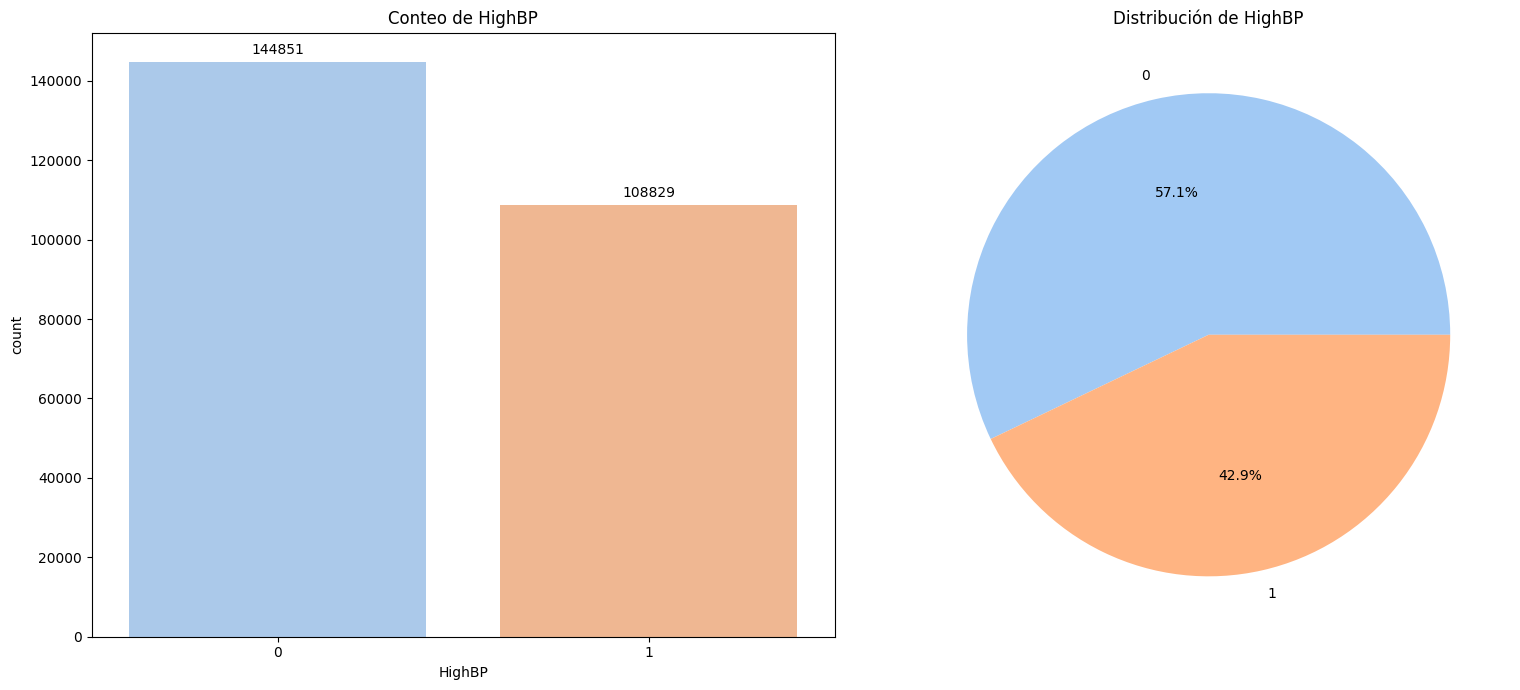

Column: HighChol


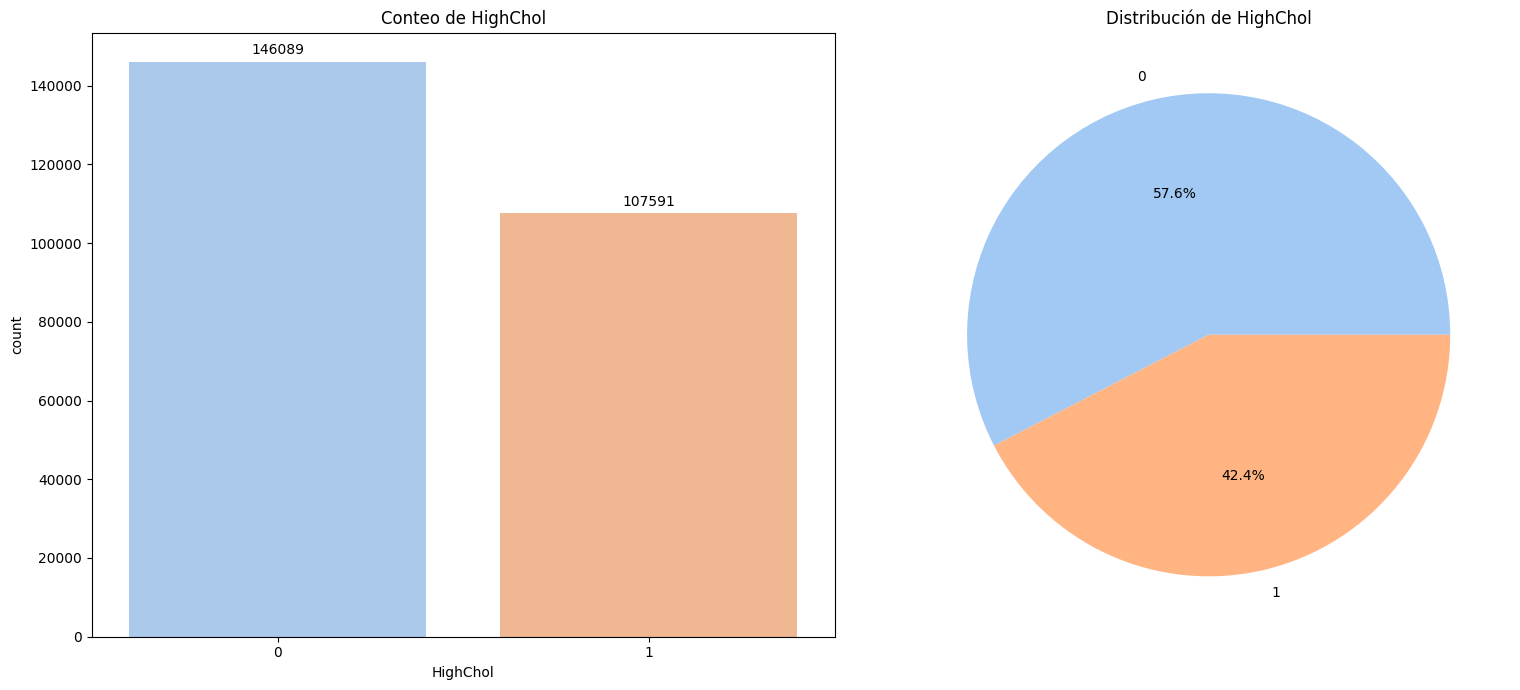

Column: CholCheck


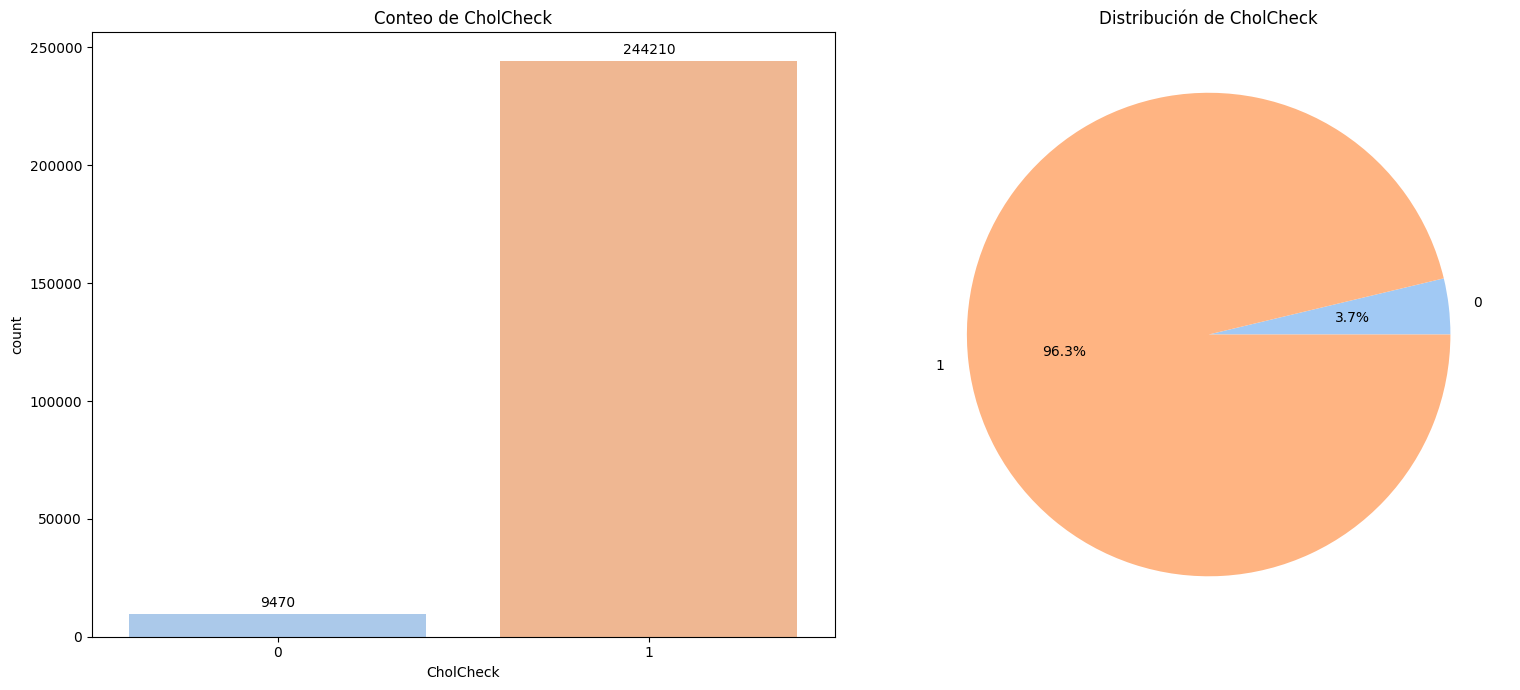

Column: Smoker


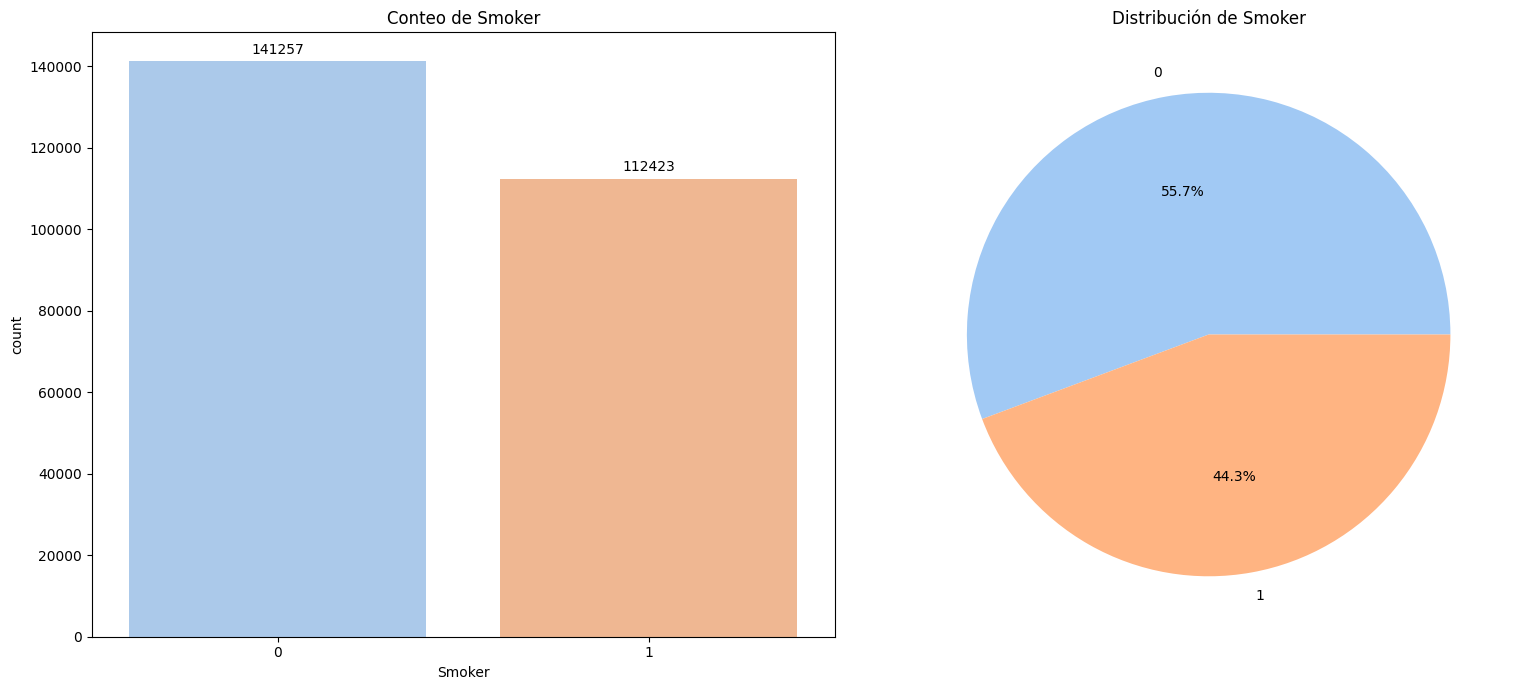

Column: Stroke


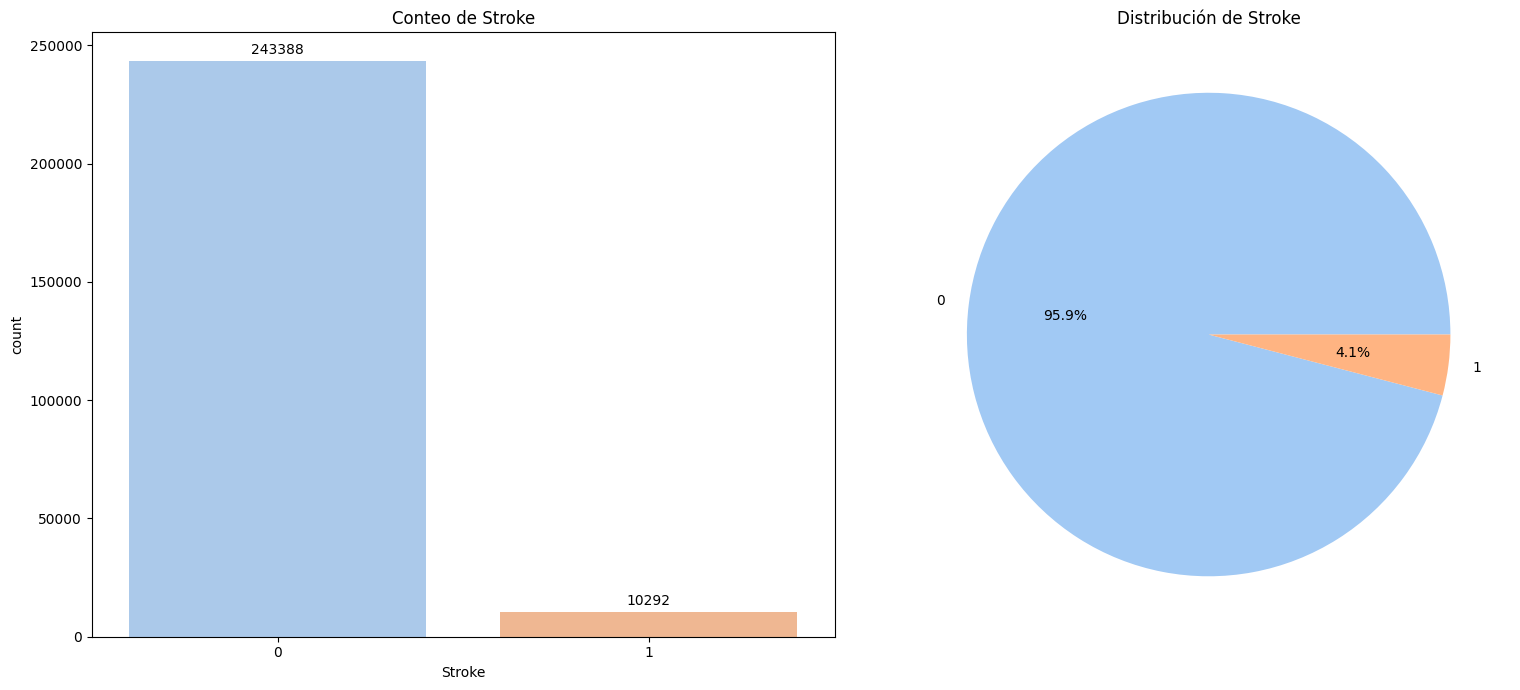

Column: HeartDiseaseorAttack


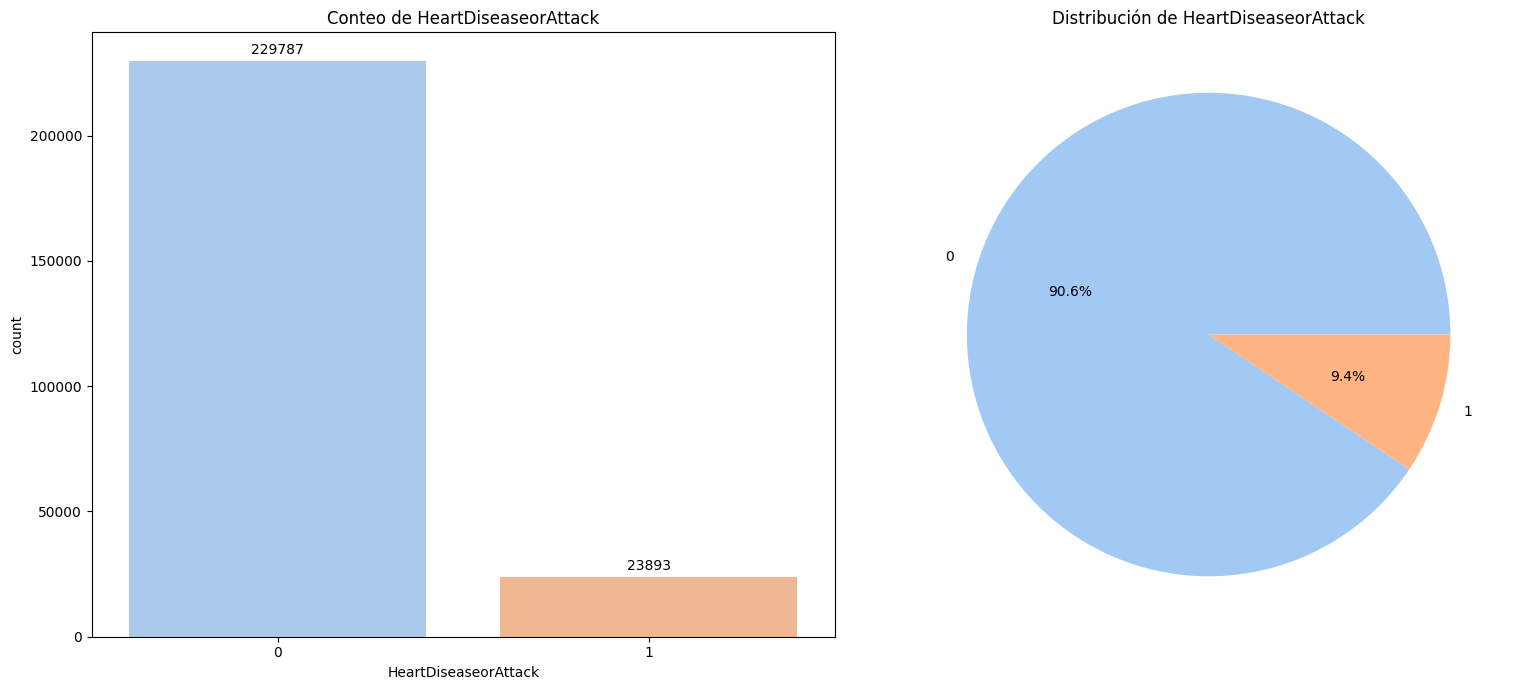

Column: PhysActivity


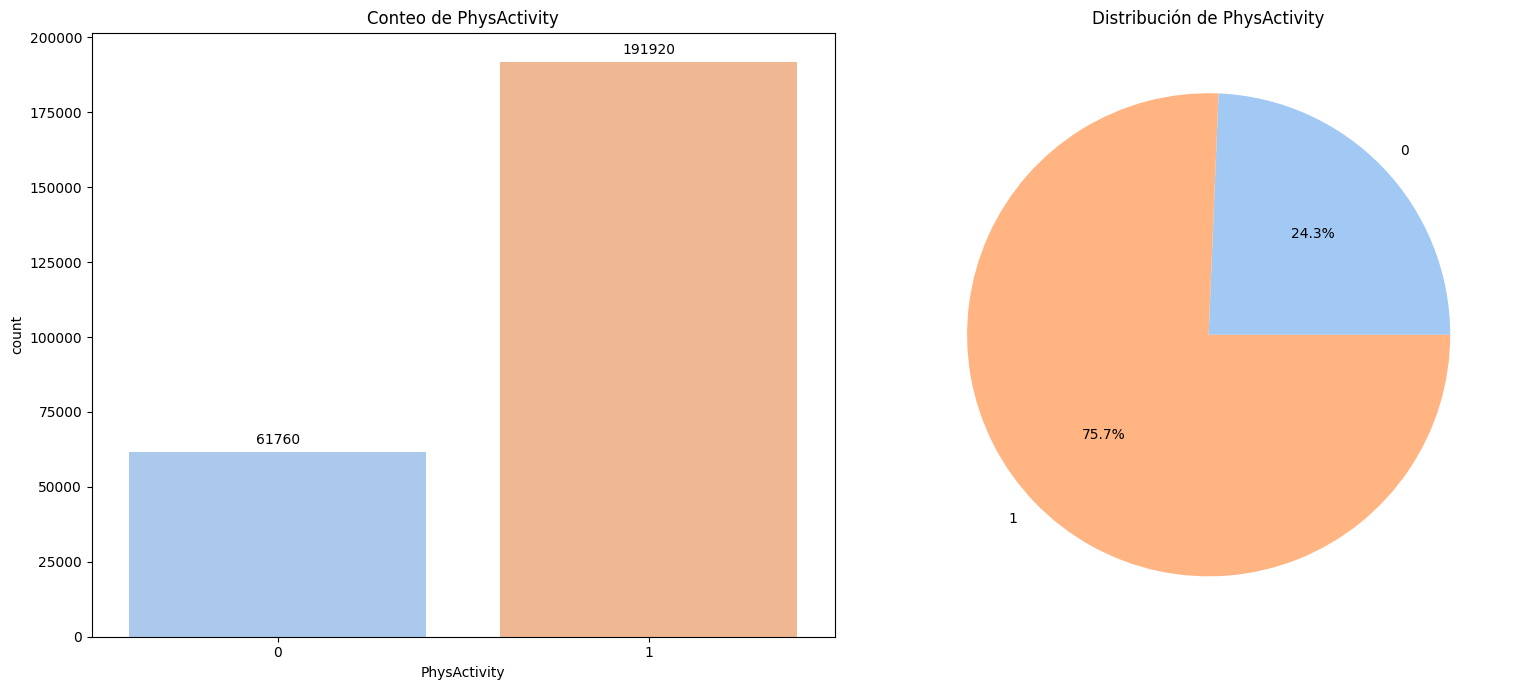

Column: Fruits


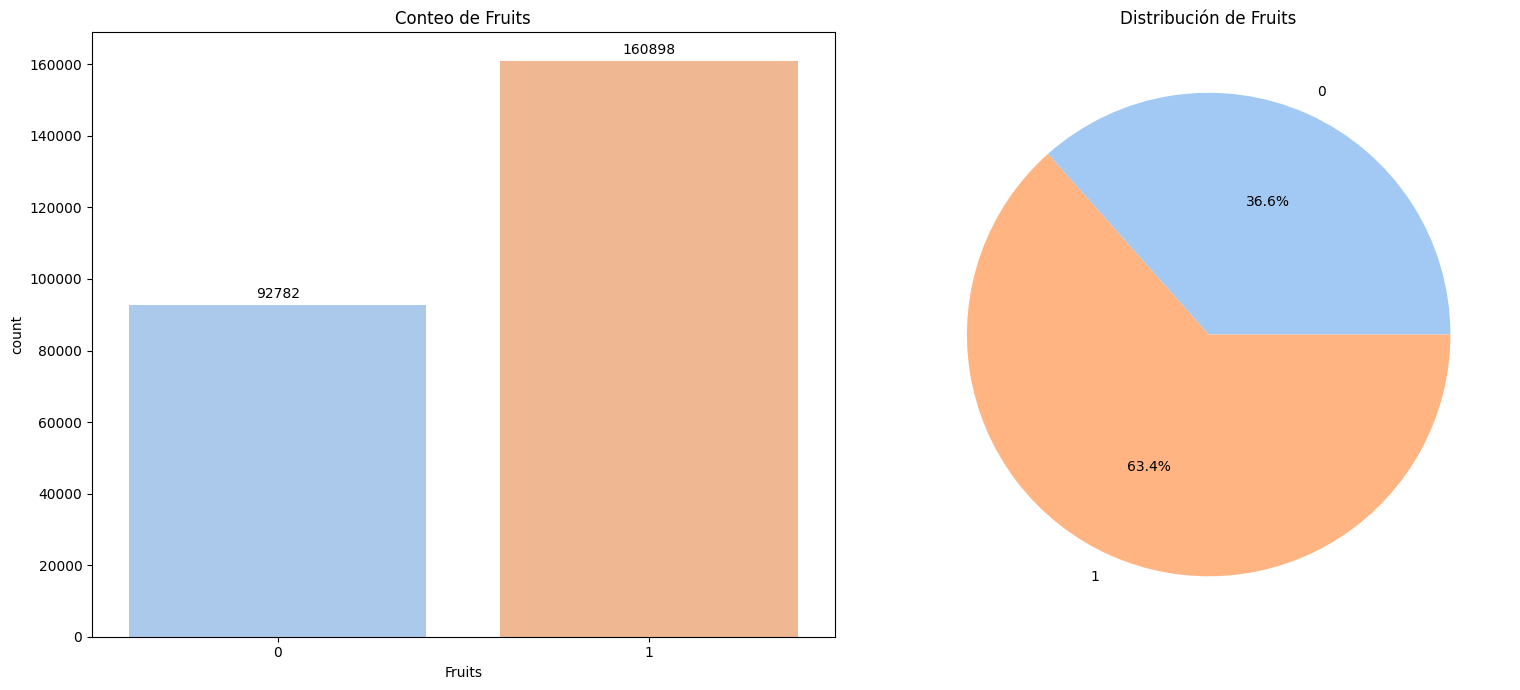

Column: Veggies


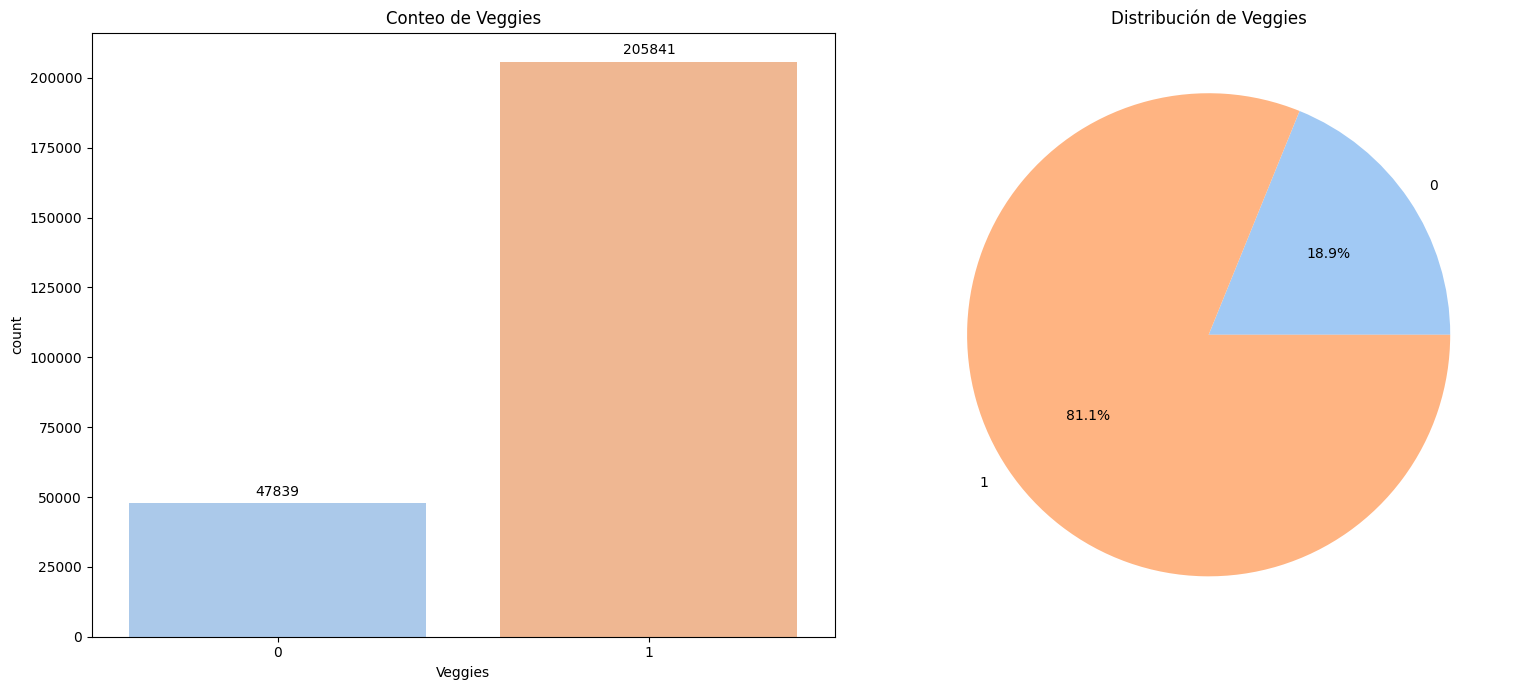

Column: HvyAlcoholConsump


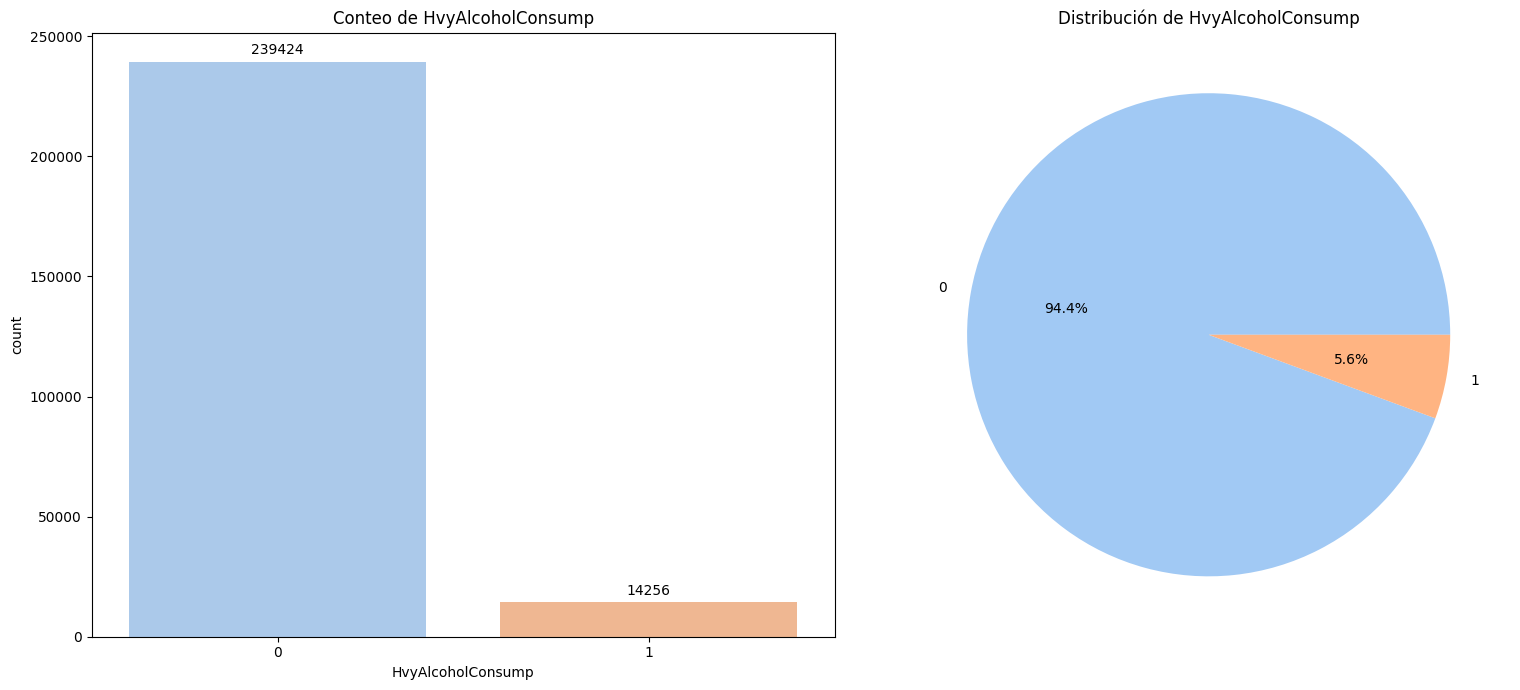

Column: AnyHealthcare


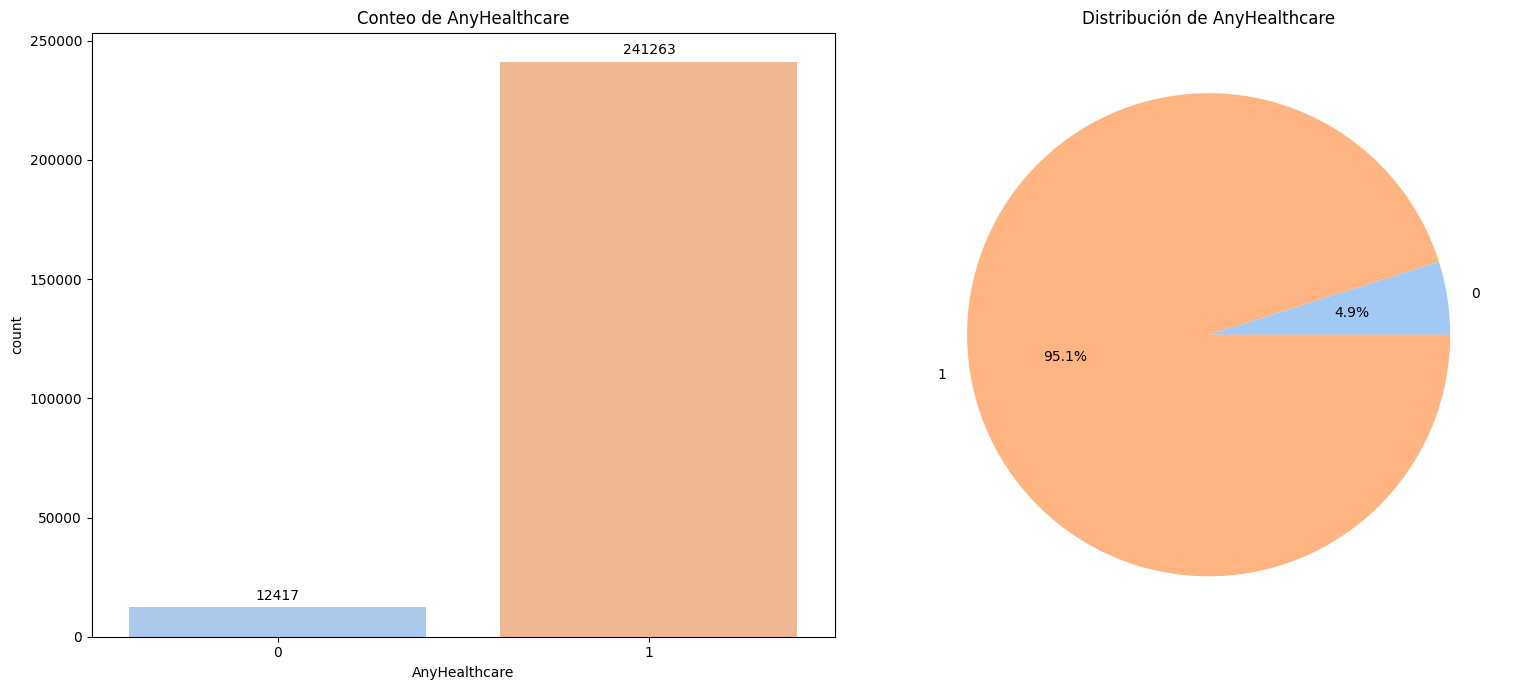

Column: NoDocbcCost


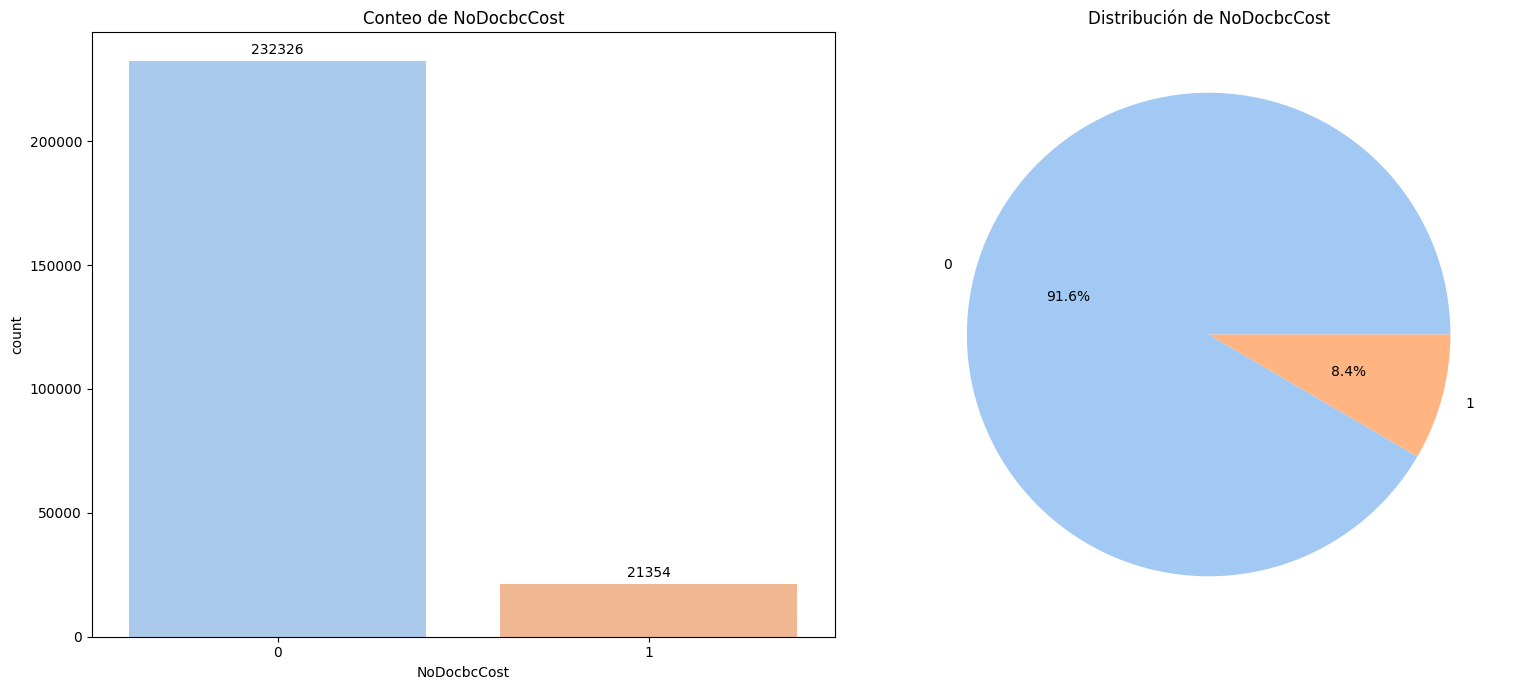

Column: DiffWalk


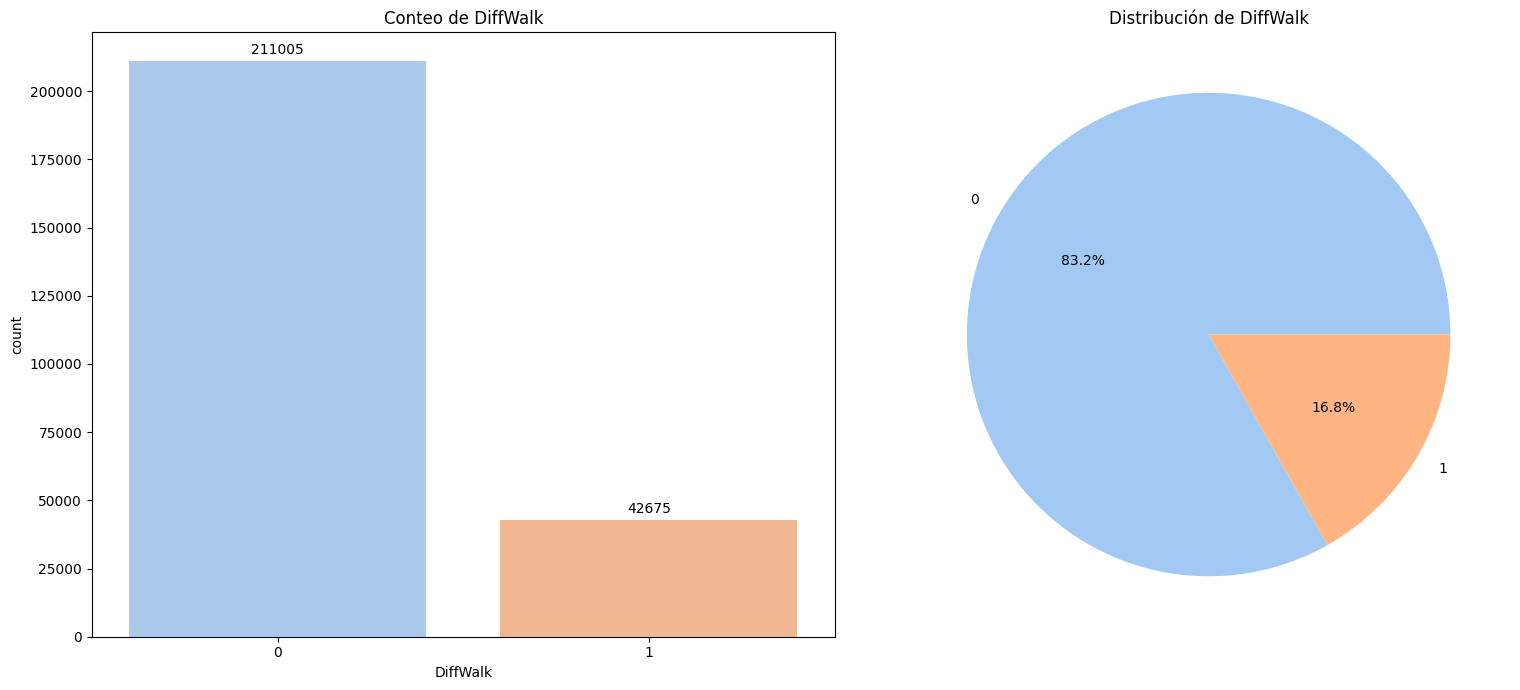

Column: Sex


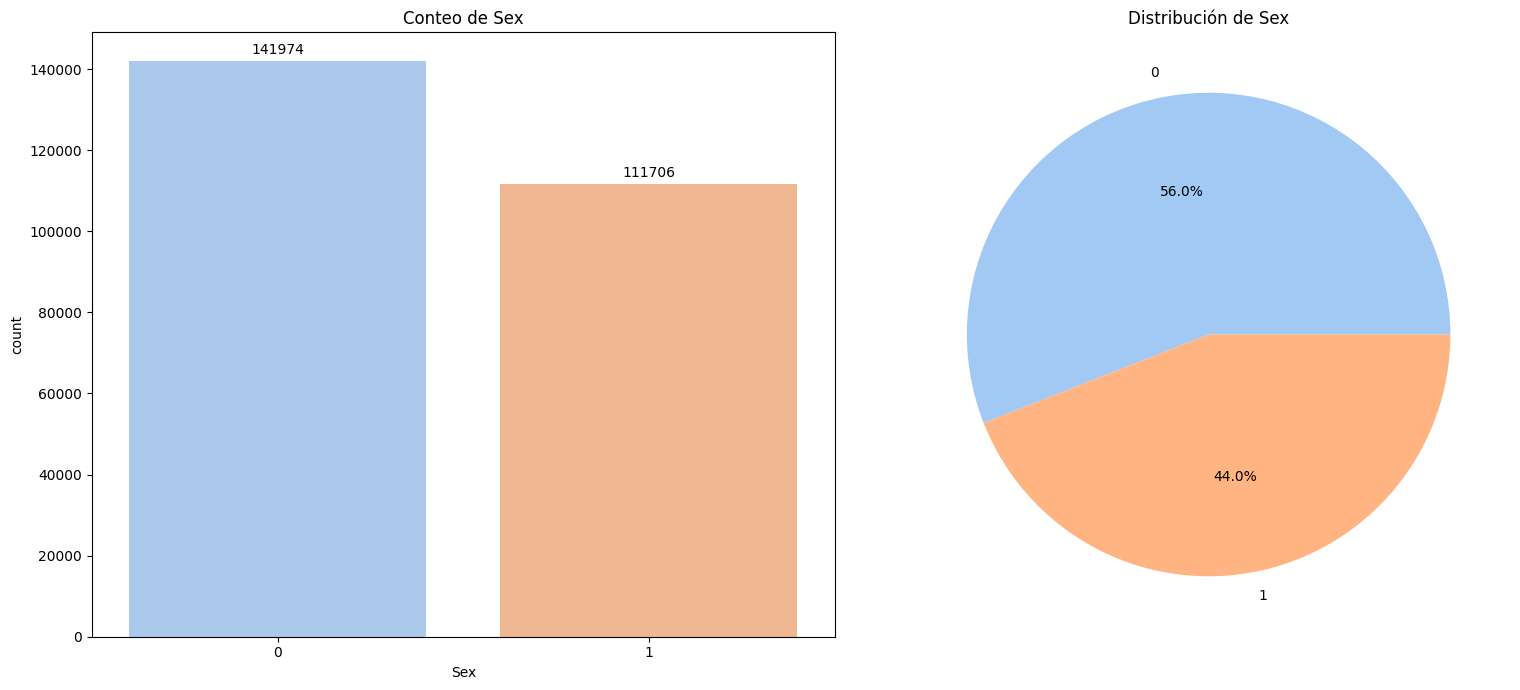

Column: Diabetes_binary


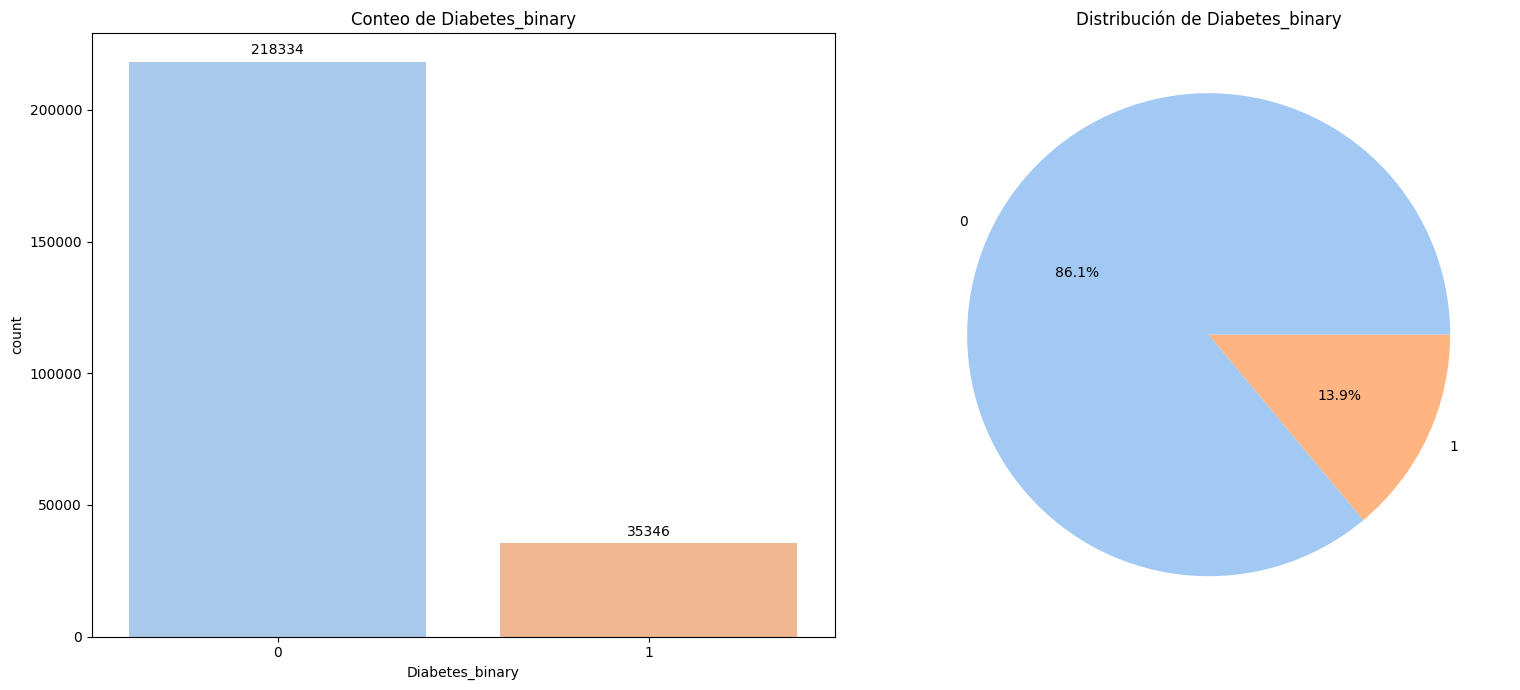

In [324]:
for col in binarias:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Definir el orden y los colores consistentes
    value_order = sorted(df[col].unique())
    colors = sns.color_palette('pastel')  # Misma paleta para ambos gráficos
    
    # Primer subplot - Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    # Añadir los valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    
    # Segundo subplot - Diagrama de torta
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order]  # Ordenar los conteos
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)  # Usar la misma paleta ordenada
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Binarias:**

El análisis de las proporciones revela un marcado desbalance en varias variables binarias, lo que tiene implicaciones importantes para el análisis y modelado:

- Variables con Distribución Relativamente Equilibrada: Algunas características como `HighBP` (42.9% positivos) y `HighChol` (42.4% positivos) presentan una distribución cercana al equilibrio, lo que facilita su análisis sin necesidad de ajustes especiales. Esto sugiere que estas condiciones son comunes en la población estudiada, lo que podría reflejar factores de riesgo prevalentes en el perfil demográfico de la muestra.

- Desbalance Moderado: Variables como `Fruits` (36.6% negativos) y `Veggies` (18.9% negativos) muestran un desbalance moderado. Aunque no son extremos, estos casos podrían beneficiarse de técnicas en modelos predictivos para asegurar que la clase minoritaria tenga suficiente representación en las predicciones.

- Desbalance Extremo: En contraste, variables como `Stroke` (4.1% positivos), `HvyAlcoholConsump` (5.6% positivos) e incluso la variable objetivo `Diabetes_binary` presentan un desbalance pronunciado, donde la clase positiva es significativamente menor. Esto implica riesgos como:

    - Sesgo en Modelos: Los algoritmos podrían ignorar la clase minoritaria al optimizar la precisión global, subestimando patrones críticos.

    - Sobreajuste: Con tan pocos casos positivos, el modelo podría memorizar ruido en lugar de aprender relaciones generalizables.

### Variables Categóricas

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. Cada gráfico muestra:

- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas según su escala natural.

Column: GenHlth


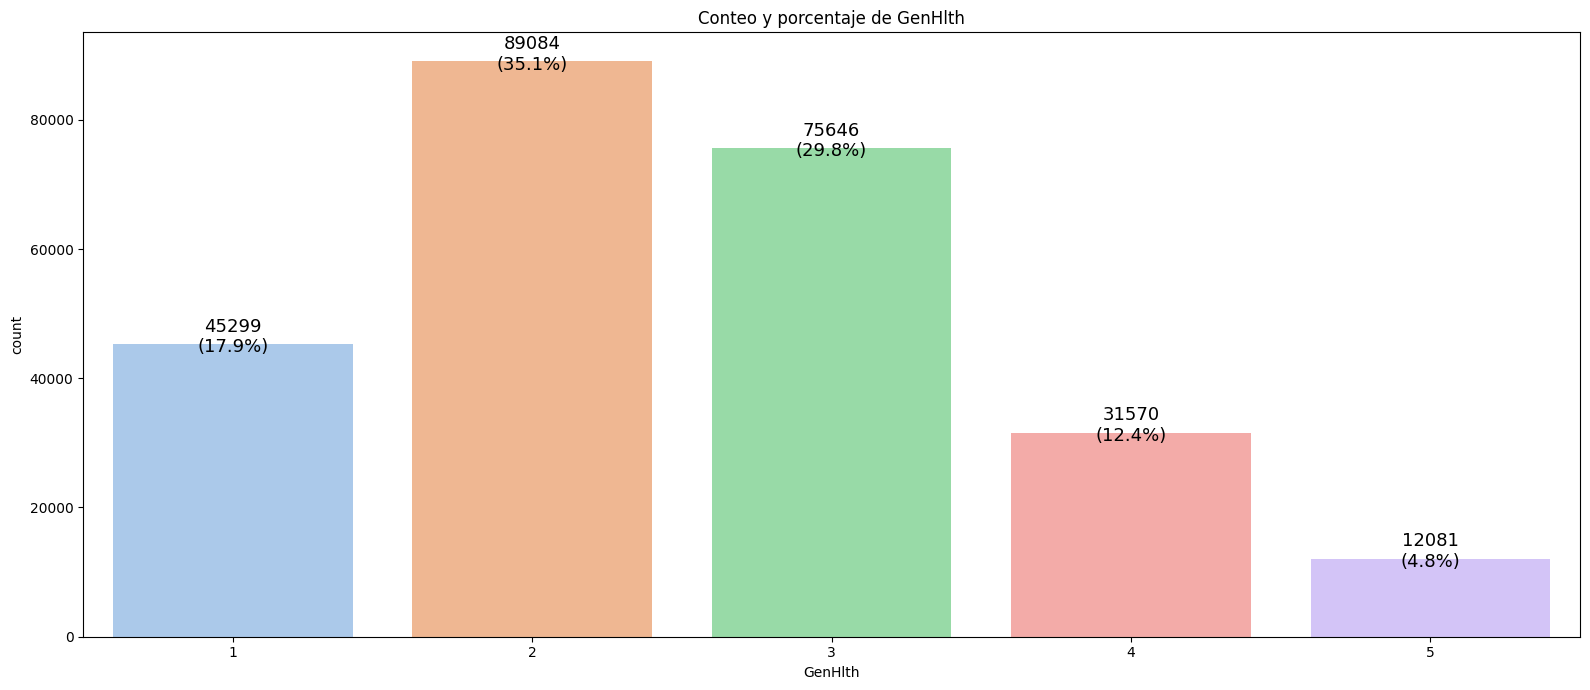

Column: Age


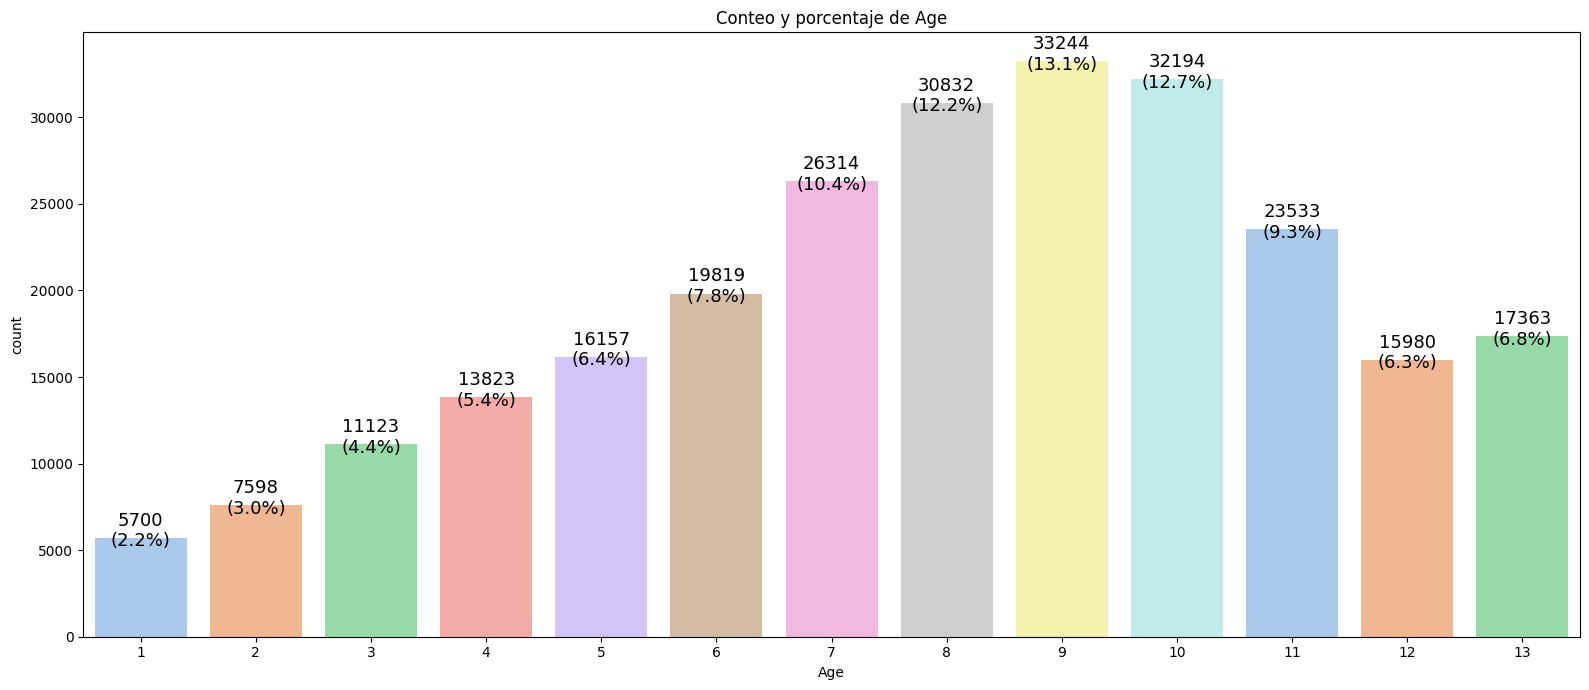

Column: Education


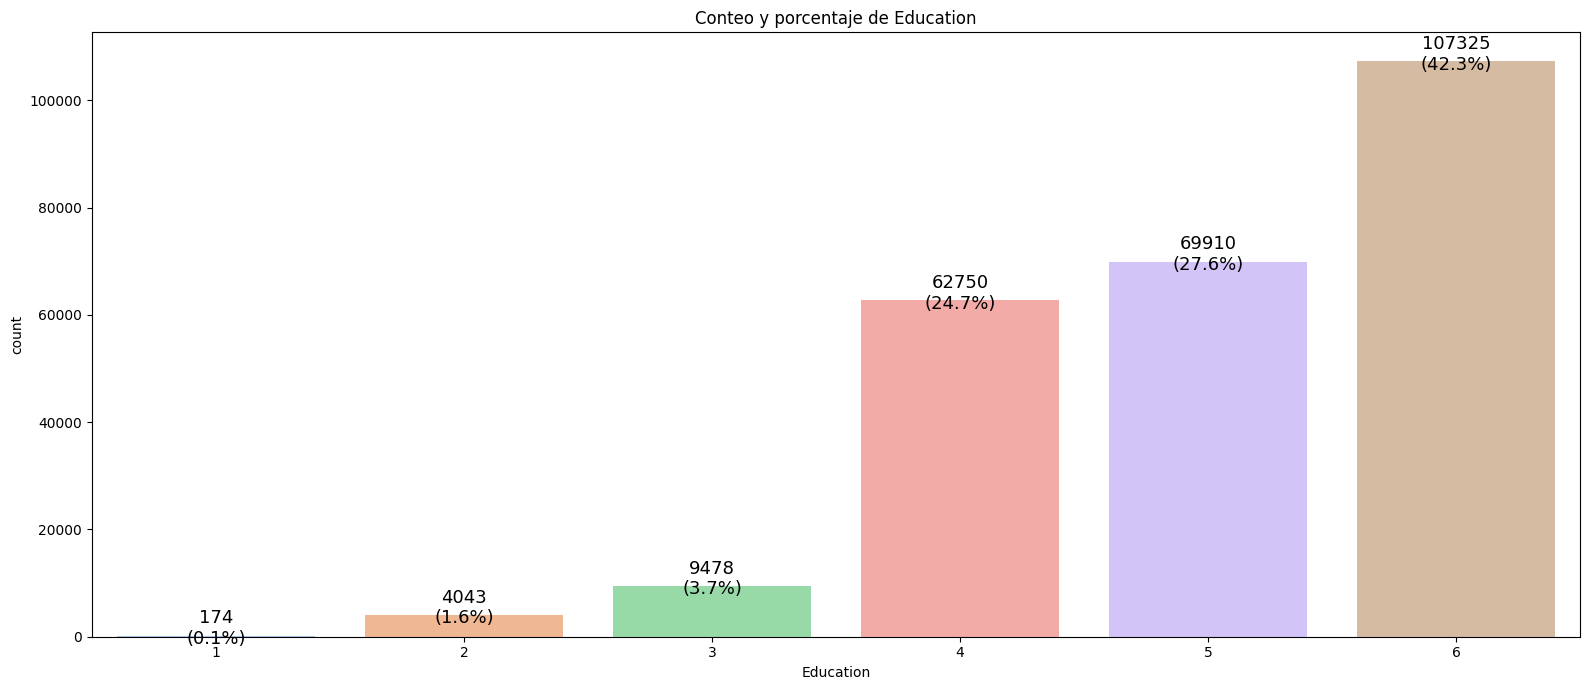

Column: Income


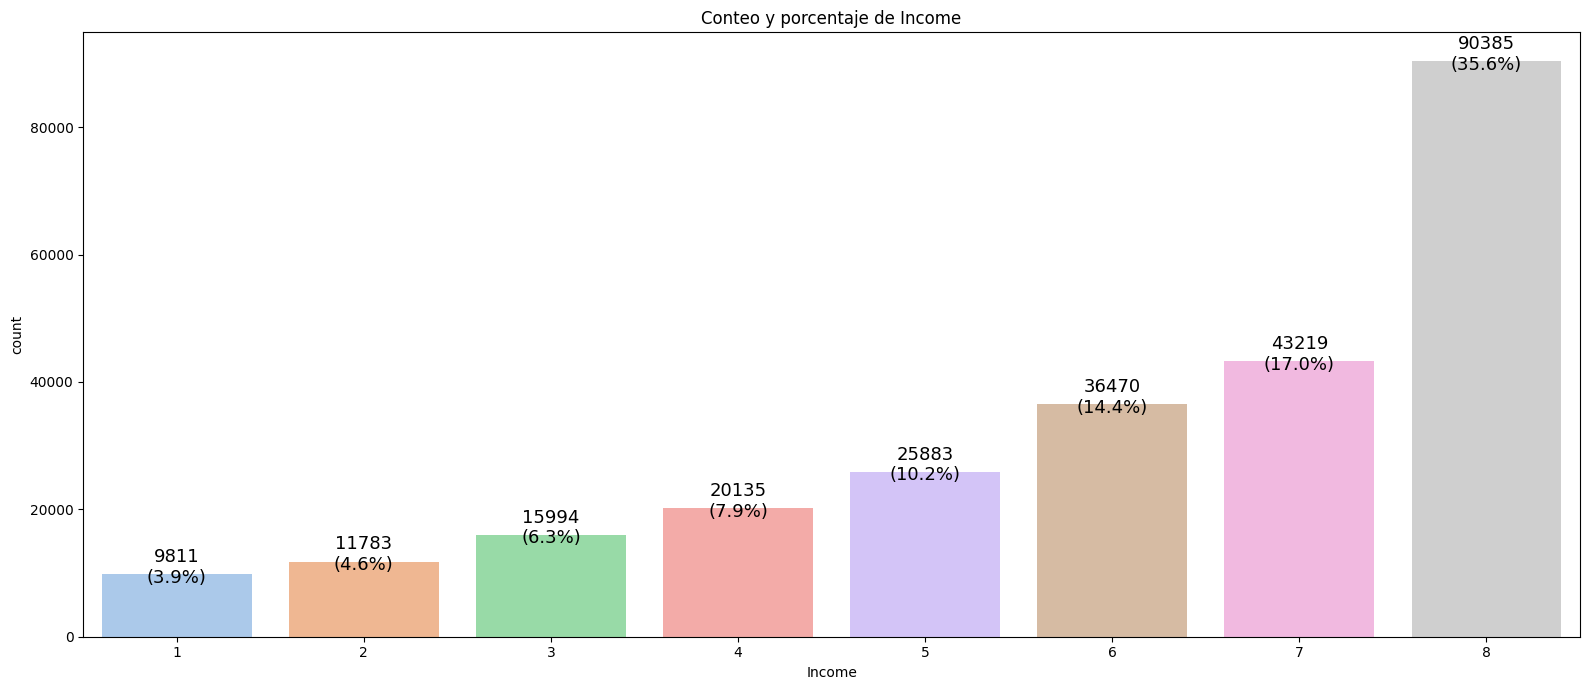

In [325]:
categoricas = ['GenHlth', 'Age', 'Education', 'Income']

for col in categoricas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Obtener el orden de las categorías según el diccionario
    value_order = sorted(df[col].unique())  
    
    # Crear el gráfico de barras ordenado
    ax = sns.countplot(x=df[col], order=value_order, palette='pastel')
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=13)
    plt.title(f'Conteo y porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()
  

**Interpretación de Variables Categóricas:**

El análisis de las distribuciones revela patrones demográficos y socioeconómicos clave en la población estudiada:

- `GenHlth`
La distribución muestra una tendencia hacia percepciones positivas de salud: el 53.0% de los encuestados reporta salud "muy buena" (35.1%) o "excelente" (17.9%), mientras solo el 4.8% la califica como "pobre".

- `Age`
 Se observa una concentración alta en edades entre 50 y 69 años (grupos 7 a 10), lo cual sugiere que la mayoría de los participantes o casos en este conjunto de datos son personas de mediana edad a adultos mayores. Los grupos con menor representación son:
    - 18–24 años (grupo 1): 5,700 personas (2.2%).
    - 25–29 años (grupo 2): 7,598 personas (3.0%),
Esto indica que hay menos jóvenes en el conjunto de datos, posiblemente porque se trata de una muestra relacionada con condiciones de salud que afectan más a personas mayores.

-  `Education`
Se observa una marcada sobrerrepresentación de educación superior: el 42.3% corresponde a graduados universitarios (categoría 6), seguido por "algo de universidad" (27.6%). Esto se evidencia al compararlo con el 0.1%, 1.6% y 3.7% de las categorias 1, 2 y 3 respectivamente. Este perfil sugiere un sesgo de selección hacia población con mayor acceso a educación, lo que podría limitar la generalización de hallazgos a grupos menos educados.

- `Income`
La distribución económica muestra una concentración en la clase media-alta: el 35.6% pertenece a la categoría más alta, seguido por la segunda categoría mas alta con 17%. Esta estructura, combinada con los datos educativos, refuerza la hipótesis de que la muestra subrepresenta poblaciones vulnerables.

### Variables Númericas

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [326]:
df[['MentHlth', 'PhysHlth','BMI']].describe().T

,count,mean,std,min,25%,50%,75%,max
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0


**Interpretación de Variables Númericas:**

- `MentHlth`: Los participantes reportaron un promedio de 3.18 días con salud mental afectada en los últimos 30 días. Con una desviación estándar de 7.41 días, indicando una variabilidad moderada en las respuestas.
- `PhysHlth`: El promedio fue ligeramente mayor (4.24 días), sugiriendo que los problemas físicos son más frecuentes que los mentales en esta muestra. Con una dispersión mayor (desviación estándar de 8.72 días), lo que sugiere que los problemas físicos muestran mayor variabilidad entre los individuos.

Ambas variables comparten un patrón similar en los percentiles:
- 25% inferior: 0 días de afectación.
- Mediana (50%): 0 días.
- 75% superior: 2 días para salud mental y 3 días para salud física.

Este patrón revela que la mayoría de la población (al menos 50%) no reportó días con problemas de salud.

- `BMI`: El Índice de Masa Corporal (BMI) muestra una media de 28.38 y una desviación estándar de 6.61, indicando que la mayoría de los valores se agrupan alrededor de 28.38, con una dispersión moderada. La distribución está sesgada hacia valores más altos.
    - Mediana (50%): 27.0 < Media (28.38), lo que sugiere una cola derecha (presencia de valores atípicos altos).
    - Rango intercuartílico (IQR): 7.0 (Q3-Q1 = 31.0 - 24.0), capturando el 50% central de los datos.
    - Valores extremos: El mínimo (12.0) y máximo (98.0) son atípicos, especialmente el máximo (98.0), que está muy alejado del percentil 75% (31.0).

---

Se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- Asimetría:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- Kurtosis: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

Column: MentHlth
Skew: 2.72
Kurtosis:  6.44
Coeficiente de Variación:  232.76 %


<Figure size 1600x700 with 0 Axes>

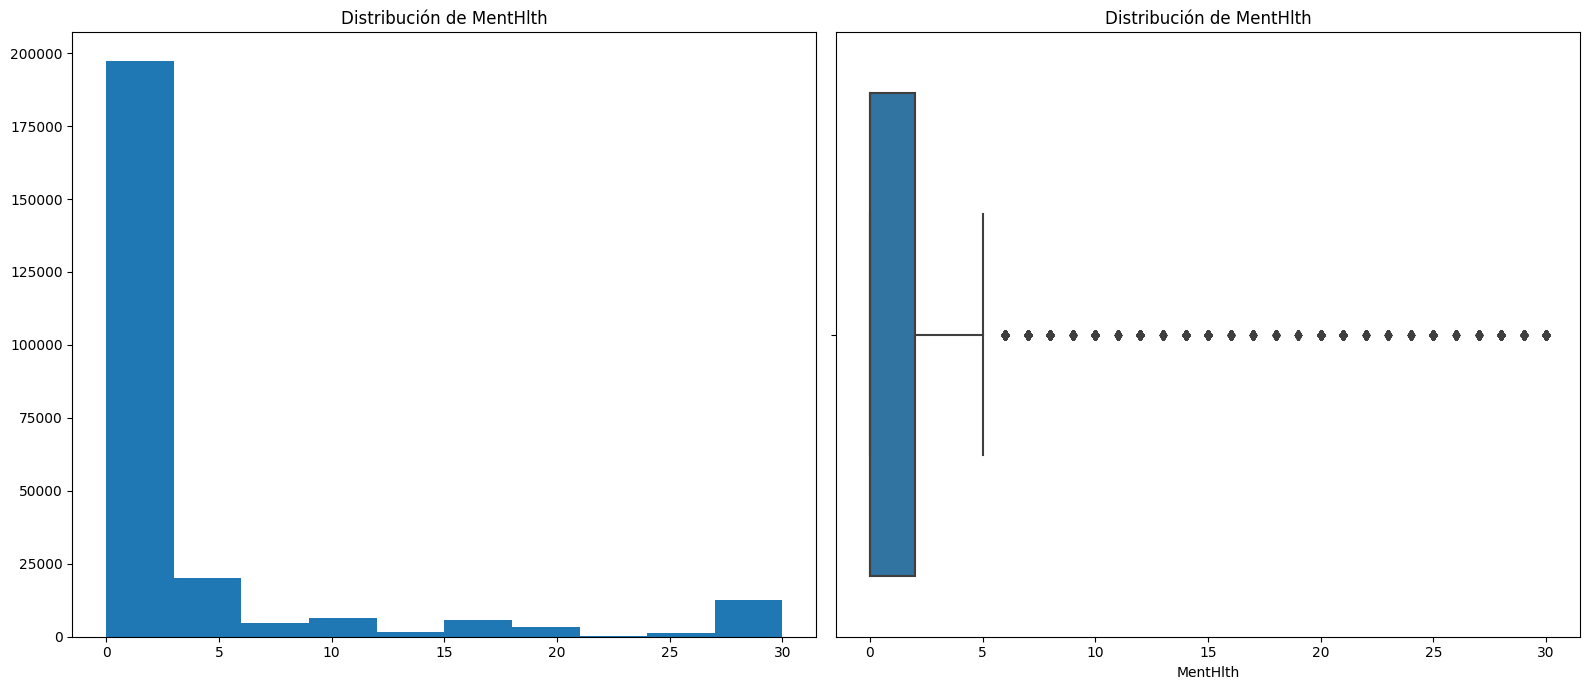

Column: PhysHlth
Skew: 2.21
Kurtosis:  3.5
Coeficiente de Variación:  205.51 %


<Figure size 1600x700 with 0 Axes>

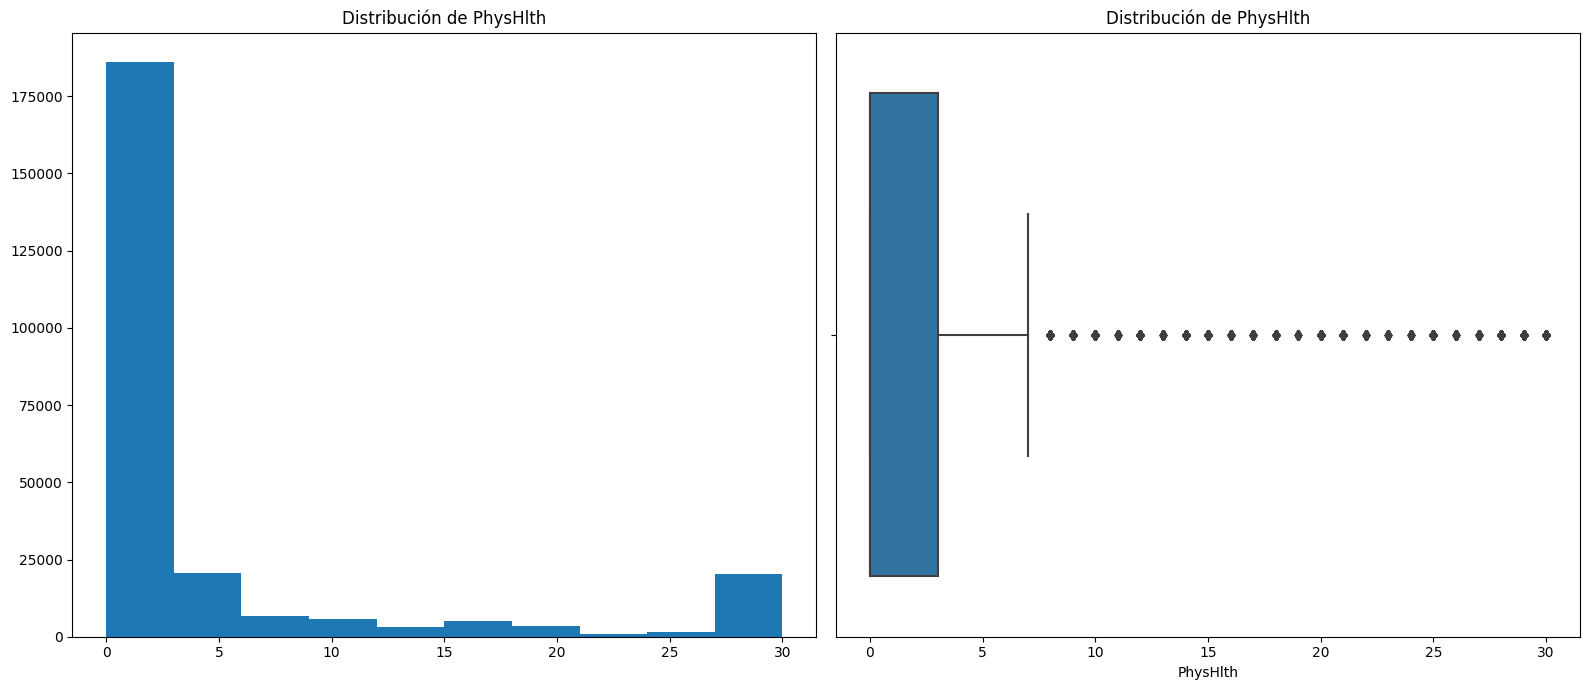

Column: BMI
Skew: 2.12
Kurtosis:  11.0
Coeficiente de Variación:  23.28 %


<Figure size 1600x700 with 0 Axes>

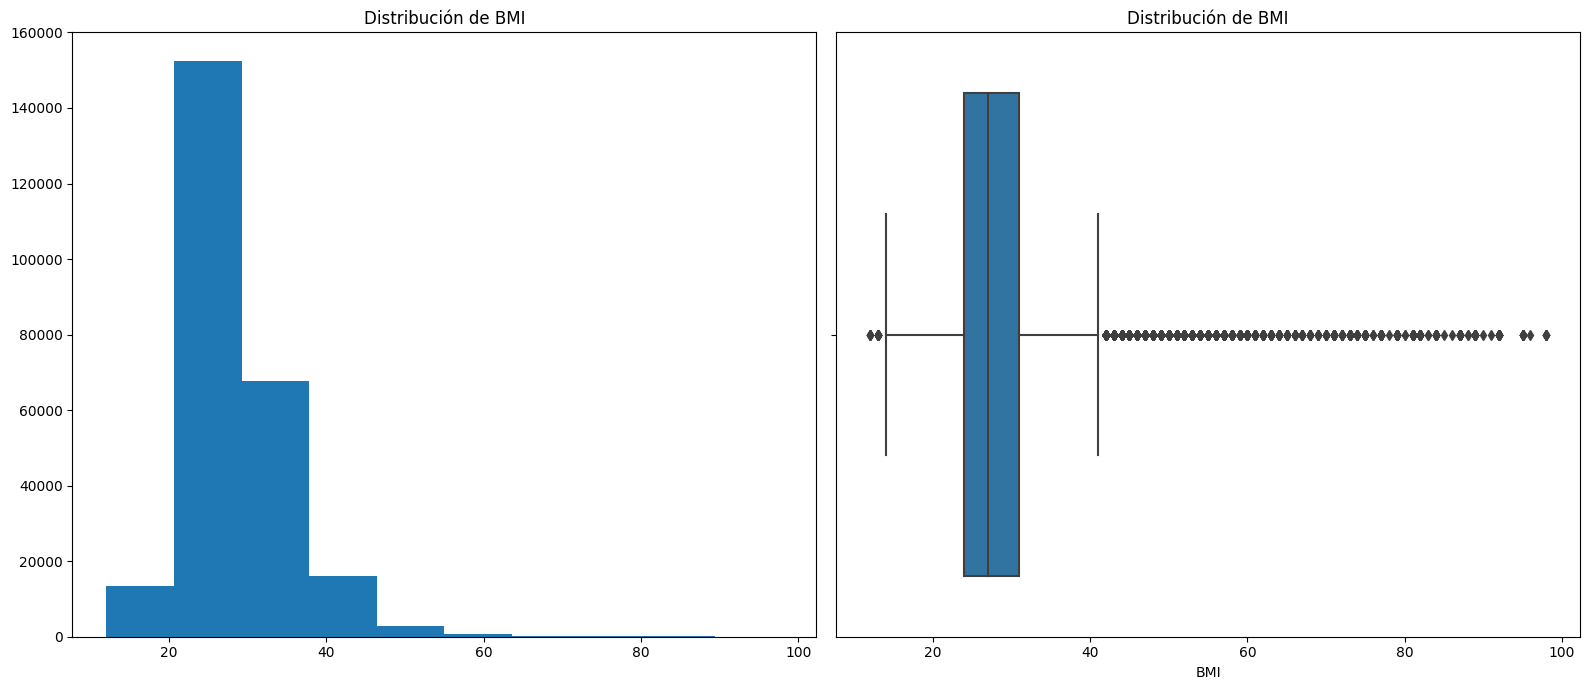

In [327]:
numericas = ['MentHlth', 'PhysHlth', 'BMI']

from scipy.stats import kurtosis

for col in numericas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize = (16, 7))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False)
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Númericas:**

Los datos muestran que la variable `MentHlth` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.72) con una kurtosis elevada (6.44), indicando:
- Una concentración extrema de valores bajos (cerca de 0 días).
- Una larga cola hacia valores altos.
- Presencia significativa de outliers, como evidencia el boxplot.
Esta distribución sugiere que la mayoría de la población reporta pocos o ningún día de afectación mental, mientras que un pequeño grupo muestra afectación persistente.

La variable `PhysHlth` también muestra sesgo positivo (skewness = 2.21) pero con una kurtosis menos pronunciada (3.5), lo que revela:
- Similar concentración en valores bajos.
- Cola derecha menos extrema que MentHlth.
- Menor cantidad de outliers extremos.

Los datos muestran que la variable `BMI` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.12) con una kurtosis muy elevada (11.0), lo que indica:
- Una concentración extrema de valores en el rango bajo a moderado (probablemente entre 20-30).
- Una cola derecha muy larga que se extiende hacia valores altos de BMI.
- Presencia significativa de outliers extremos en los valores superiores.

Esta distribución sugiere que:
- La mayoría de la población tiene valores de BMI dentro del rango normal o ligeramente elevado.
- Existe un grupo más pequeño pero significativo con obesidad moderada.
- Un grupo muy reducido presenta valores extremadamente altos (obesidad mórbida).

La kurtosis excepcionalmente alta (11.0 vs 3.5 en PhysHlth) indica que:
- Los datos están mucho más concentrados alrededor de la media que en una distribución normal.
- Las colas son más pesadas de lo esperado.
- Los outliers son más extremos que en otras variables de salud analizadas.

Comparado con `MentHlth` y `PhysHlth`:
- El sesgo es similar pero ligeramente menos pronunciado.
- La kurtosis es notablemente más alta, mostrando mayor concentración en valores centrales.
- Los outliers parecen ser más extremos en BMI que en las variables de salud mental/física, debido a que en las variables de percepción el rango va desde 0 a 30 días del mes, en cambio el BMI no tiene limite.

En estos casos podemos realizar una transformación logarítmica que puede ayudar en la normalización, por lo que esta variable puede mantener la escala estándar con otras variables.

### Análisis de Valores Atípicos en BMI

Para la identificación de valores atípicos en la variable `BMI`, se aplicó el método del rango intercuartílico (IQR). 

In [328]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['BMI'] < limite_inferior) | (df['BMI'] > limite_superior)]
print(f"Número de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")

Número de outliers: 9847
Porcentaje de outliers: 3.88%


---
Para el tratamiento de valores atípicos en la variable `BMI`, se aplicó la técnica de winsorización al 1% en el extremo superior de la distribución. Este método fue seleccionado por: 

- Su capacidad para preservar el tamaño completo de la muestra.

- Mantener la distribución general de los datos. 

- Minimizar el impacto de valores extremos y por ser conservador con la información original. 

El nivel del 1% se determinó en base al análisis previo de outliers, que mostró un 3.88% de valores atípicos, permitiendo un tratamiento balanceado que aborda la mayoría de los casos extremos sin alterar significativamente la estructura de los datos.

In [329]:
df['BMI'] = winsorize(df['BMI'], limits=[0, 0.01])
y_reg = df['BMI']

Se verifican los cambios realizados.

In [330]:
df['BMI'].describe().T

count    253680.000000
mean         28.277681
std           6.049009
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          50.000000
Name: BMI, dtype: float64

**Interpretación**

1. Reducción de la desviación estándar: 
   - De 6.61 a 6.05 (-8.5%).
   - Indica menor dispersión y datos más homogéneos, pero manteniendo variabilidad.

2. Rango corregido:
   - Mínimo: Se mantuvo en 12.0 (se preservaron valores bajos clínicamente relevantes).
   - Máximo: De 98.0 a 50.0 (dentro de rangos médicos realistas).
   - Se conservaron casos de bajo peso que podrían ser clínicamente válidos según la literatura.

3. Media ajustada:
   - De 28.38 a 28.28 (-0.10 puntos).
   - Cambio mínimo, lo que indica que la distribución central se mantuvo intacta.

Lo que se mantuvo estable:
- Mediana (50%): 27.0 → 27.0 (sin cambios).
- Primer cuartil (25%): 24.0 → 24.0 (sin cambios).  
- Tercer cuartil (75%): 31.0 → 31.0 (sin cambios).
- Tamaño de muestra: 253,680 → 253,680 (preservado).

La winsorización superior al 1% fue exitosa porque:
- Eliminó valores extremos clínicamente improbables en el extremo superior (BMI 98).
- Preservó valores bajos que pueden representar casos reales de bajo peso o desnutrición.
- Preservó completamente la distribución central (cuartiles idénticos).
- Mantuvo el tamaño de la muestra original.
- Redujo la varianza sin distorsionar la tendencia central.
- Los nuevos límites superiores (50) están dentro de rangos médicamente posibles mientras se conserva la variabilidad natural en valores bajos.

---
Se genera un histograma y un boxplot para visualizar la nueva distribución de frecuencias y dispersión de los datos.

Column: BMI
Skew: 1.06
Kurtosis:  1.48
Coeficiente de Variación:  21.39 %


<Figure size 1600x700 with 0 Axes>

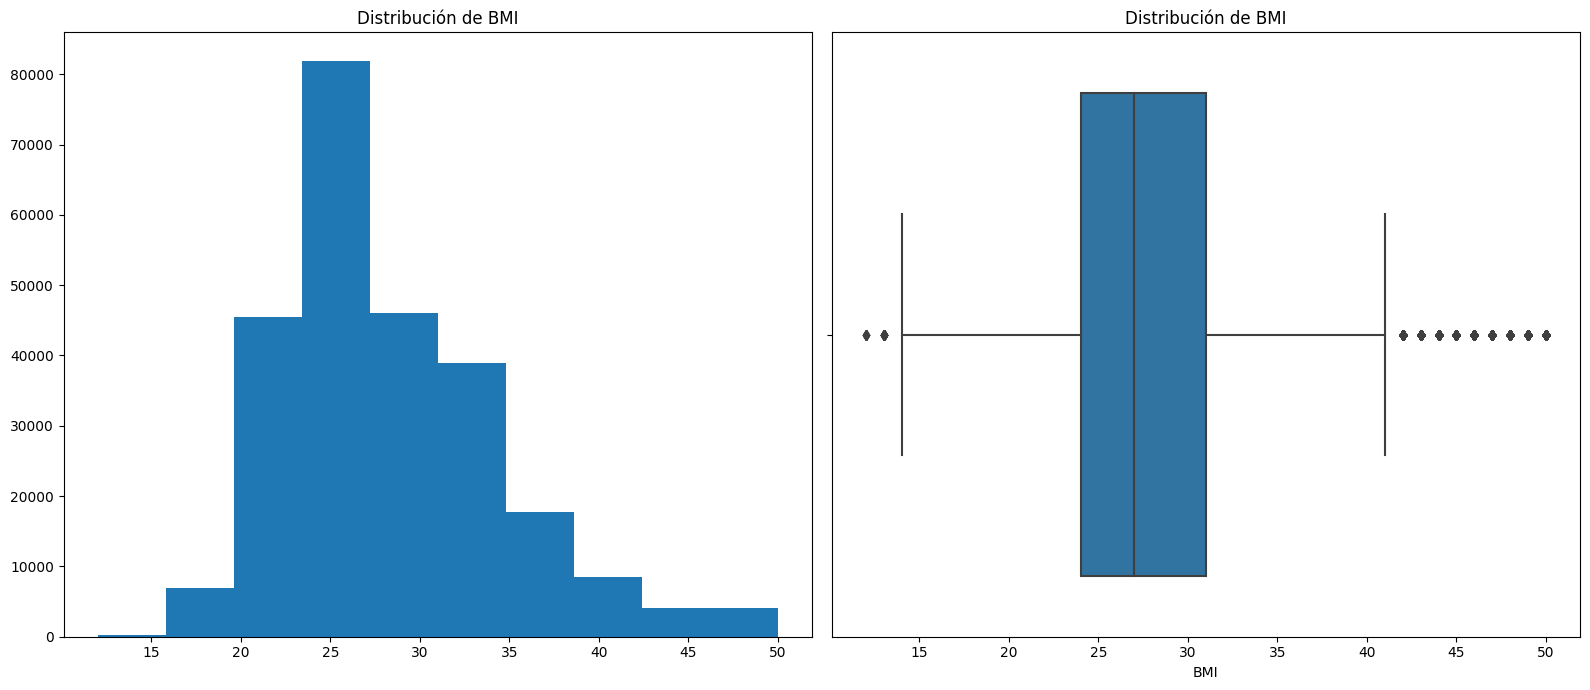

In [331]:
print('Column: BMI')
plt.figure(figsize=(16, 7))
print('Skew:', round(df['BMI'].skew(), 2))
print('Kurtosis: ', round(df['BMI'].kurtosis(), 2))
coef_variacion = (df['BMI'].std()/ df['BMI'].mean() ) * 100
print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
plt.figure(figsize = (16, 7))
plt.subplot(1, 2, 1)
df[col].hist(grid=False)
plt.title(f'Distribución de BMI')
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f'Distribución de BMI')
plt.tight_layout()
plt.show()

**Interpretación**

1. Reducción de asimetría (Skewness):
    - De 2.12 a 1.06 (-50% de reducción).
    - Interpretación: La distribución era altamente sesgada a la derecha (valores extremos altos) y ahora tiene un sesgo moderado.
    - Significado: Los valores extremos hacia la derecha (BMI altos) fueron tratados efectivamente, pero se preservó mayor asimetría natural al mantener los valores bajos intactos.

2. Mejora en curtosis (Kurtosis):
    - De 11.0 a 1.48 (-86.5% de reducción).
    - Interpretación: Pasó de una distribución extremadamente leptocúrtica (pico muy agudo y colas pesadas) a una distribución ligeramente leptocúrtica.
    - Significado: Las colas extremadamente pesadas fueron eliminadas en su mayoría, pero se mantuvo cierta curtosis al preservar la variabilidad natural en el extremo inferior.

Comparación con una distribución normal:
- Skewness ideal: 0 (perfectamente simétrica).
- Kurtosis ideal: 0 (mesocúrtica, como la normal).
- Nuevos valores: 1.06 (skew) y 1.48 (kurtosis) → Más cercanos a la normalidad que el original, pero con mayor preservación de la distribución natural.

La winsorización superior al 1% fue exitosa porque:
- Transformó una distribución altamente no-normal en una moderadamente no-normal.
- Preservó la variabilidad natural en valores bajos que pueden ser clínicamente relevantes.
- Eliminó los valores extremos superiores que causaban las colas pesadas.
- Mejoró significativamente las propiedades estadísticas para modelamiento manteniendo mayor autenticidad en la distribución.

La variable BMI ahora es adecuada para: Modelos que requieren menor influencia de outliers extremos, mientras se preserva la información clínica potencialmente valiosa en el rango inferior.

## Análisis Bivariado
El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

### Variables Binarias vs Diabetes

Se generan graficos de barras para analizar la relación entre un conjunto de variables binarias y la presencia de diabetes con el fin de identificar qué variables binarias están asociadas a mayores proporciones de diabetes en el conjunto de datos.

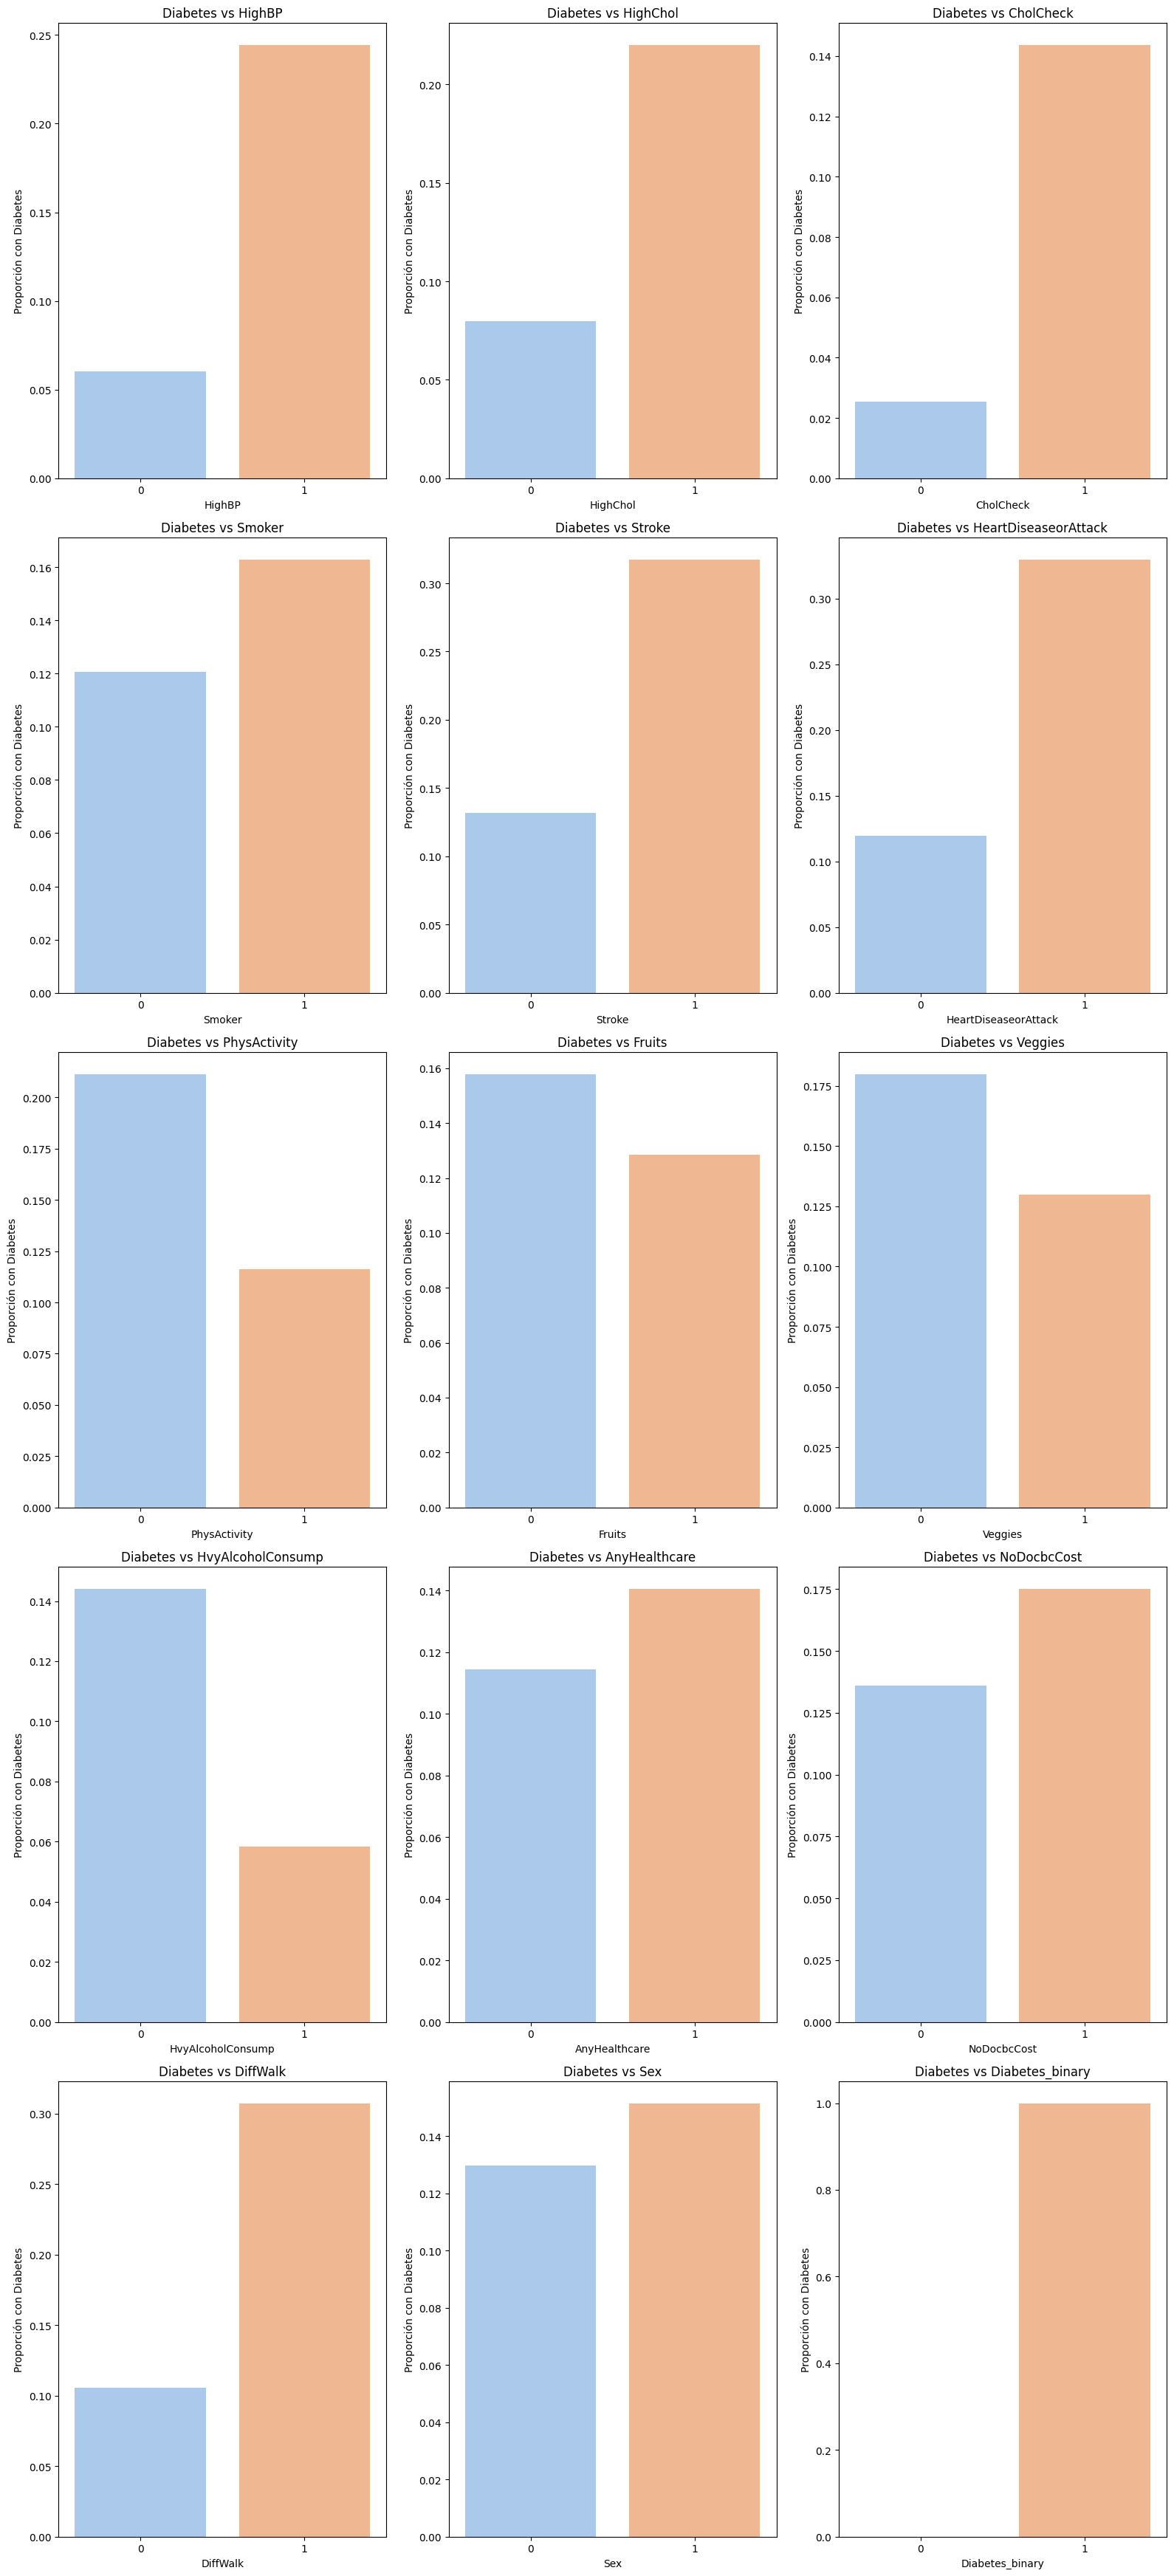

In [332]:
plt.figure(figsize=(16, 7 * 5)) 

for i, col in enumerate(binarias, 1):  
    plt.subplot(5, 3, i) 
    sns.barplot(
    x=col, 
    y='Diabetes_binary', 
    data=df, 
    palette='pastel',
    errorbar=None
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
plt.tight_layout()  
plt.show()

**Interpretación:**

Los resultados visualizados muestran que la proporción de personas con diabetes es notablemente mayor en aquellos que presentan condiciones crónicas como hipertensión, colesterol alto, enfermedades cardiovasculares, antecedentes de derrame cerebral y dificultades físicas para caminar. Esta tendencia sugiere una fuerte asociación entre la diabetes y la presencia de otras enfermedades no transmisibles. Además, se observa que ciertos comportamientos y estilos de vida, como la inactividad física y el consumo de tabaco, también están relacionados con una mayor prevalencia de diabetes. Por otro lado, factores como la actividad física regular y una alimentación con frutas y verduras parecen asociarse con una menor proporción de personas con diabetes. Finalmente, las barreras económicas y el acceso limitado a servicios de salud también muestran una posible relación con una mayor proporción de casos, lo cual resalta la importancia del contexto socioeconómico en el manejo y prevención de esta enfermedad. En conjunto, los gráficos evidencian que la diabetes no solo está influenciada por condiciones médicas, sino también por determinantes sociales y conductuales de la salud.

### Variables Categóricas vs Diabetes

Se generan graficos de barras para analizar la relación entre variables categóricas y la presencia de diabetes en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de diabetes, lo que podría indicar posibles factores de riesgo asociados.

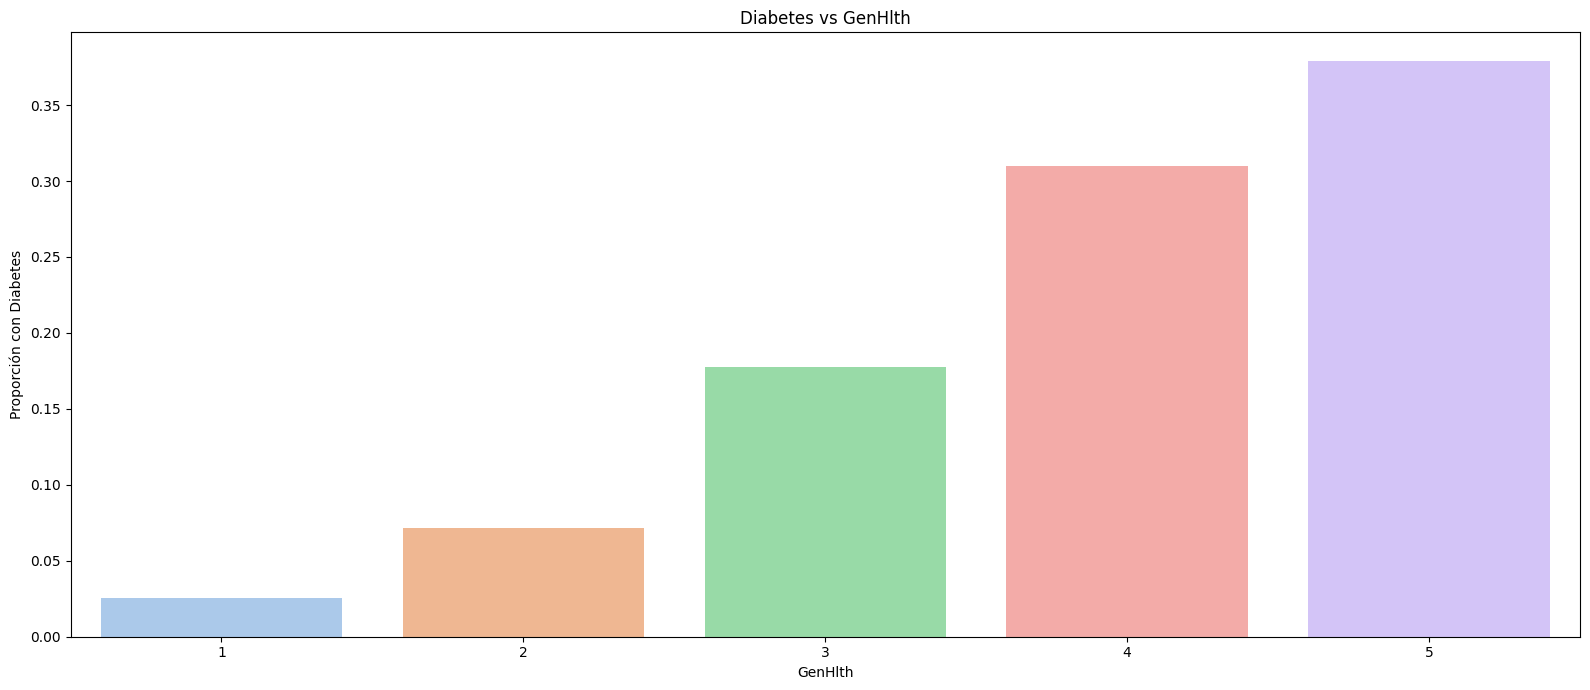

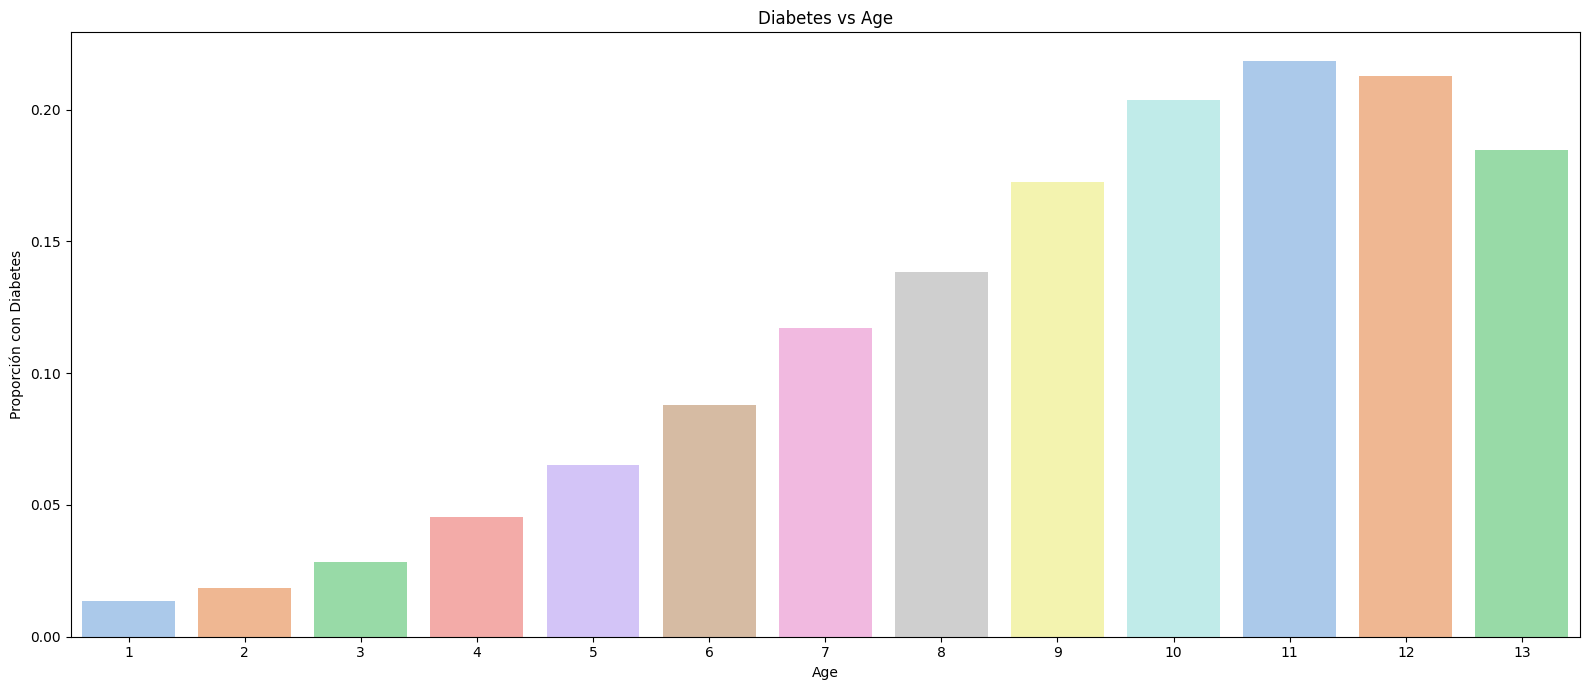

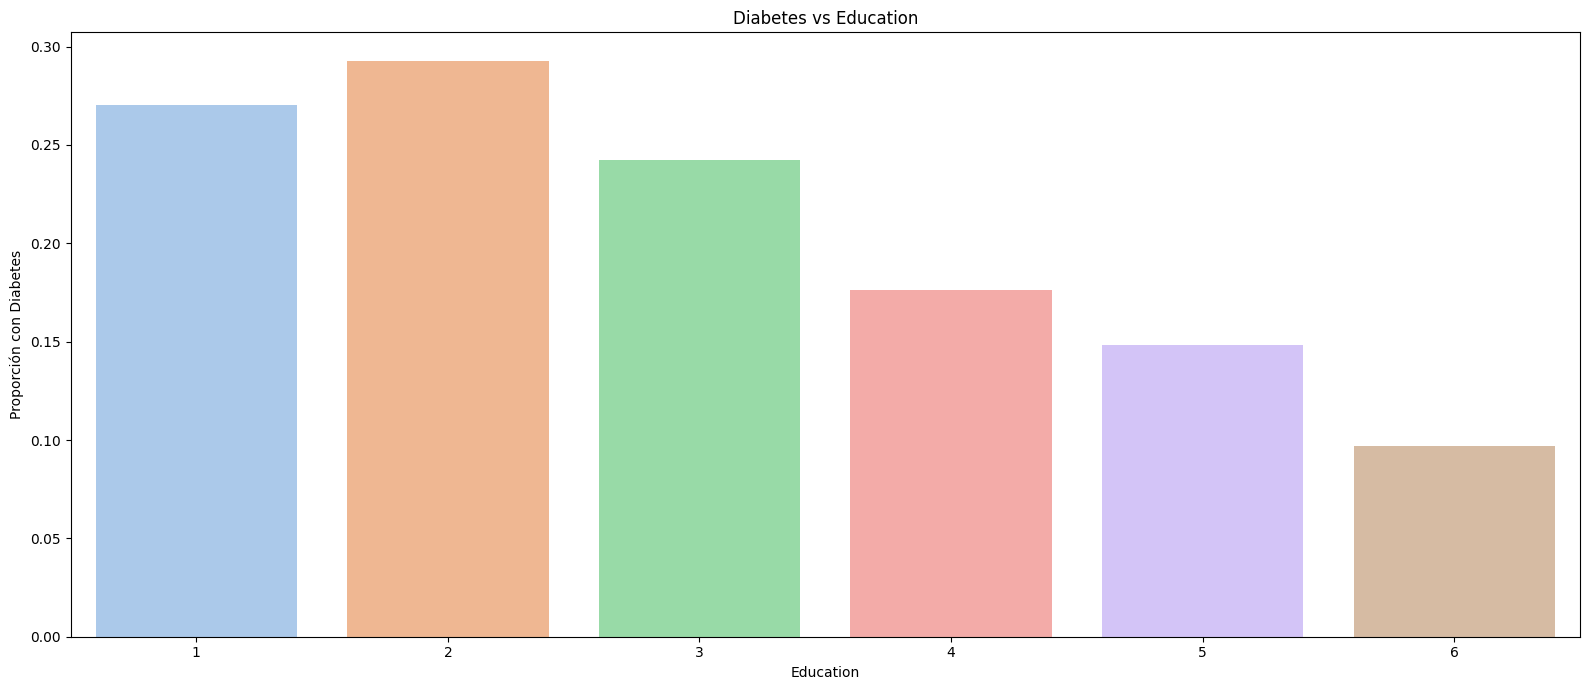

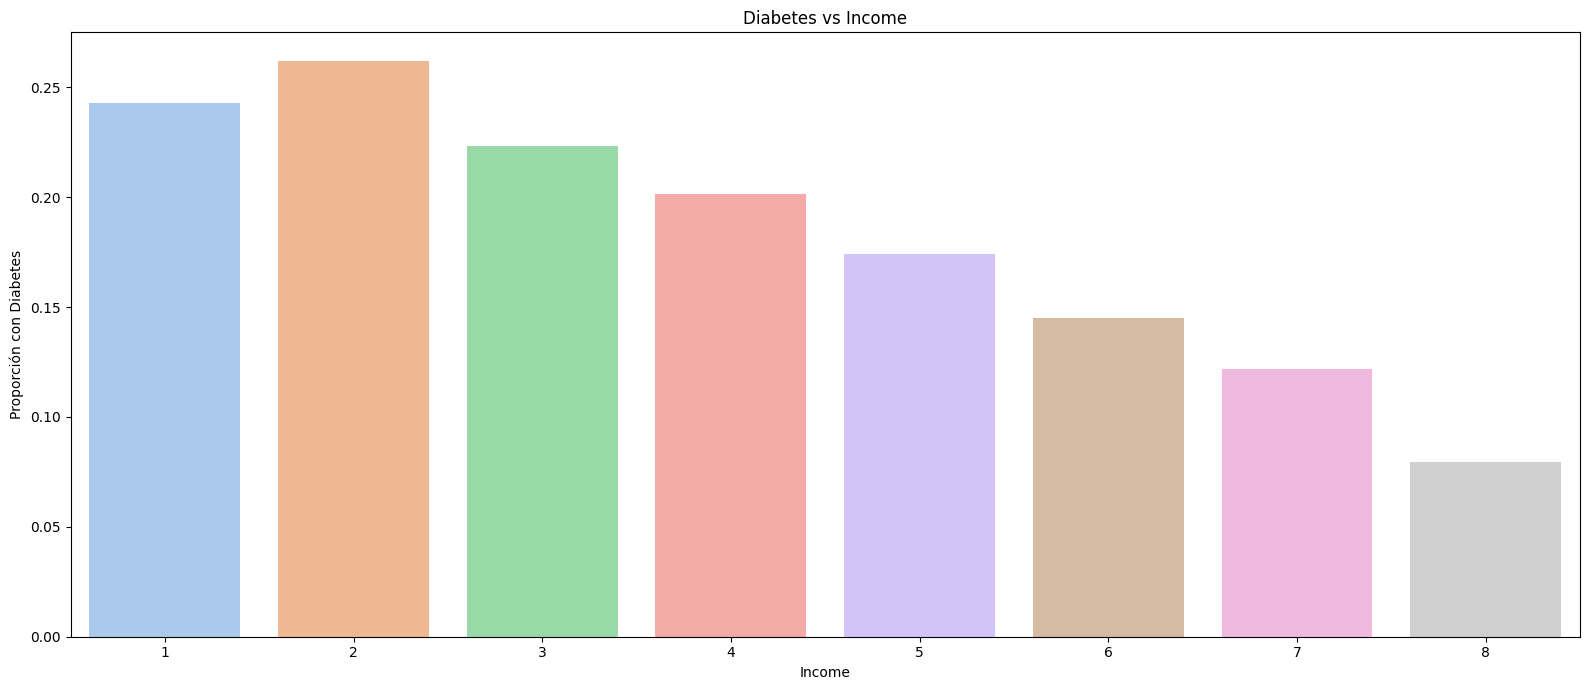

In [333]:
for col in categoricas:
    
    plt.figure(figsize=(16, 7))
    sns.barplot(
        x=col, 
        y='Diabetes_binary', 
        data=df, 
        palette='pastel',
        errorbar=None  
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
    plt.tight_layout()
    plt.show()

**Interpretación:**

Los resultados muestran una relación clara entre la proporción de personas con diabetes y diversas variables sociodemográficas. En cuanto al estado general de salud percibido `GenHlth`, se observa que a medida que las personas reportan una peor salud (del valor 1 al 5), la proporción de casos de diabetes aumenta progresivamente, lo que indica una fuerte asociación entre la autopercepción negativa de la salud y la presencia de diabetes. En relación con la `Age`, los datos revelan una tendencia ascendente en la proporción de diabetes conforme se avanza en los grupos etarios, alcanzando su punto máximo en los grupos de mayor edad, lo que sugiere que la diabetes es más común en adultos mayores. Por otro lado, los niveles de `Education` muestran una tendencia inversa: las personas con menor nivel educativo presentan una mayor proporción de diabetes, mientras que a mayor nivel educativo, esta proporción disminuye gradualmente. Esta misma tendencia se refleja en los niveles de `Income`, donde las personas con ingresos más bajos muestran una mayor prevalencia de diabetes en comparación con aquellas que pertenecen a grupos de ingresos más altos. En conjunto, estos resultados evidencian la influencia significativa de factores sociales como la edad, la educación, el ingreso económico y la percepción de salud en la prevalencia de la diabetes, resaltando la importancia de abordar esta enfermedad desde un enfoque multidimensional..

### Variables Númericas vs Diabetes

Se visualiza la asociación entre variables numéricas y la diabetes. Los gráficos combinan barras (proporción de diabetes por categoría) y una línea de tendencia (roja), permitiendo identificar patrones o relaciones monotónicas entre las variables y la variable objetivo.

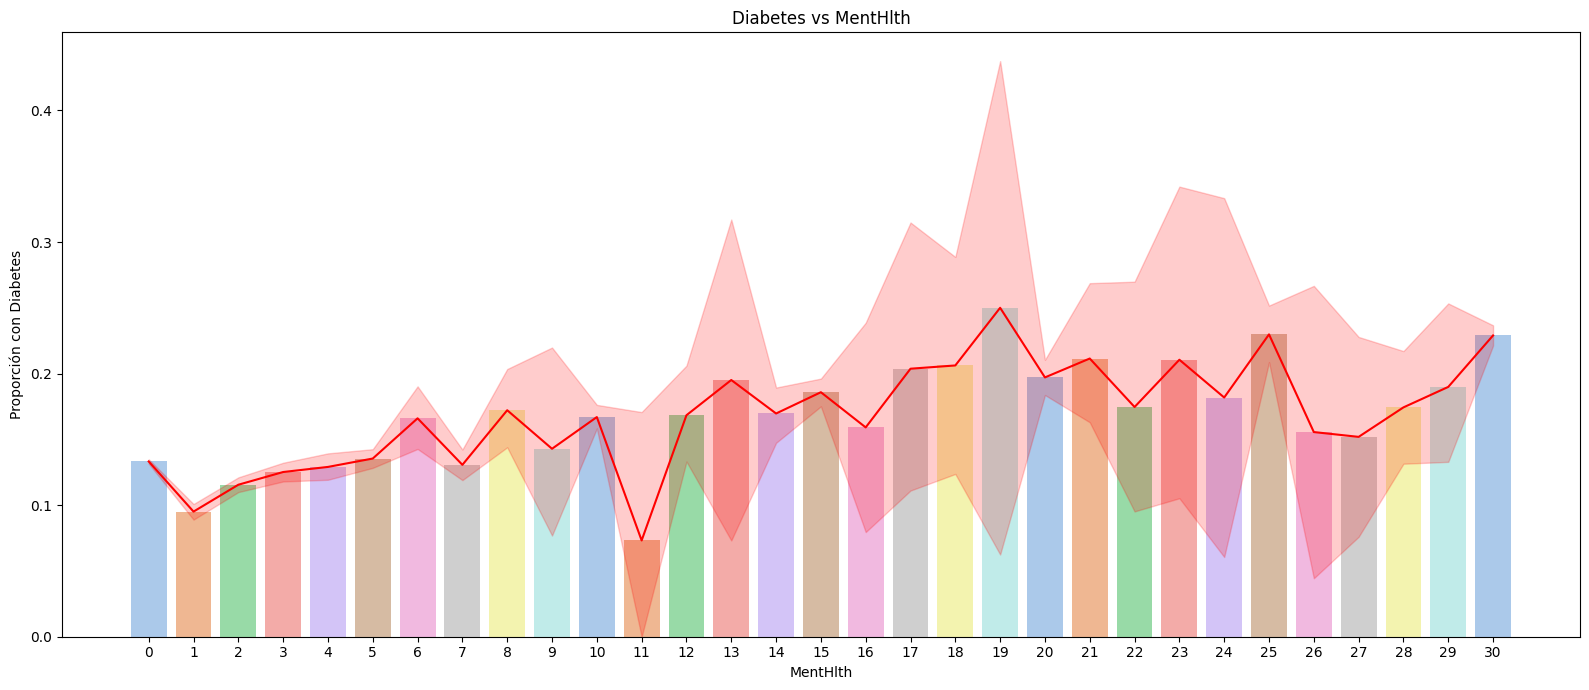

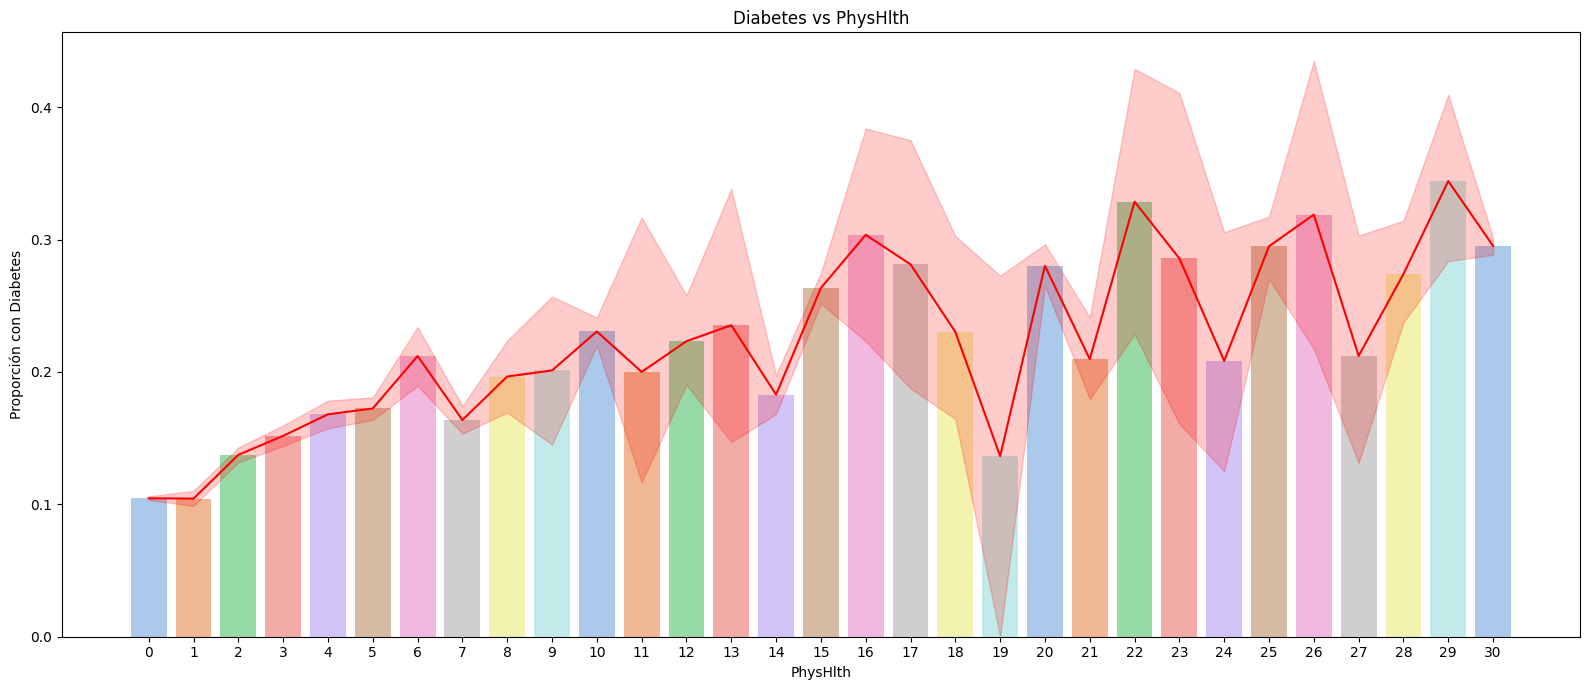

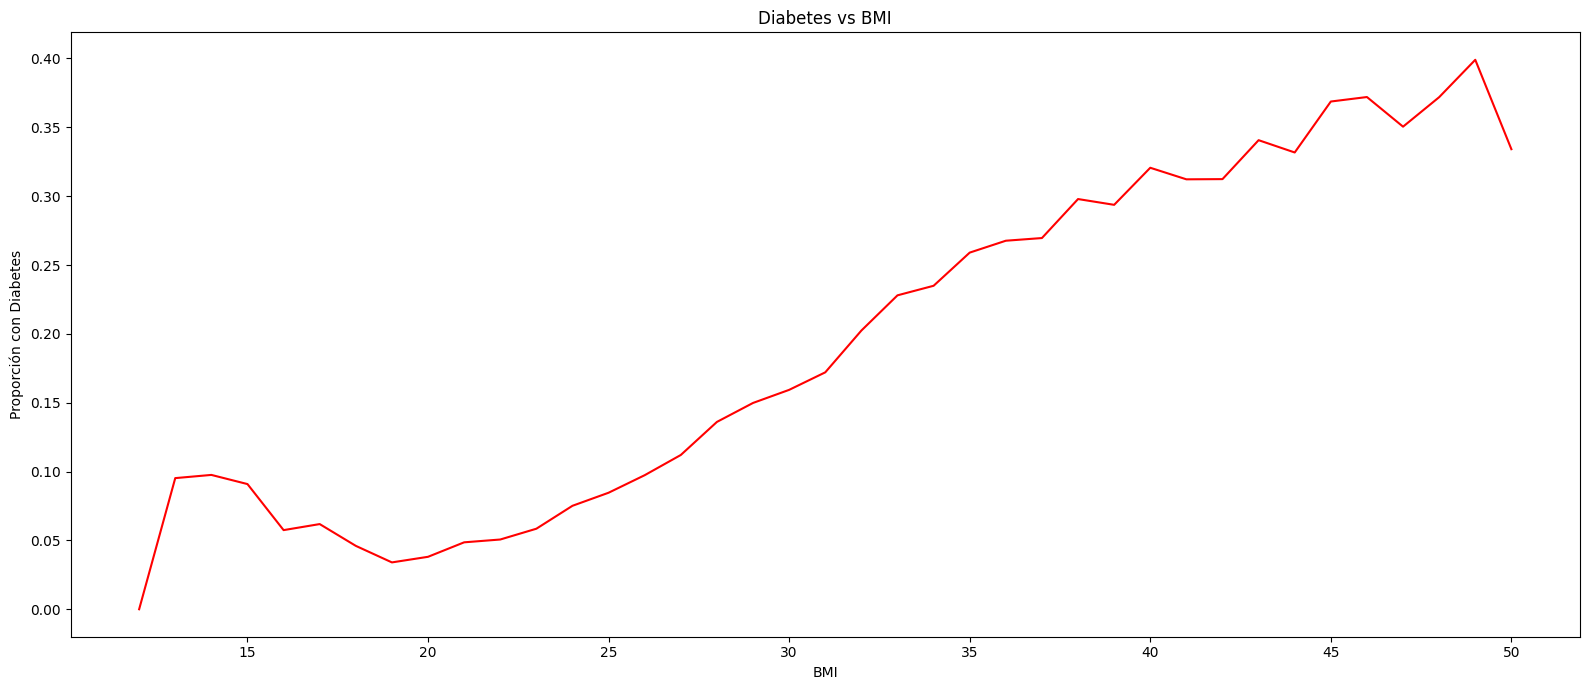

In [334]:
for col in numericas:
    
    if (col != "BMI"):
        plt.figure(figsize=(16, 7))
        sns.barplot(
            x=col, 
            y='Diabetes_binary', 
            data=df, 
            palette='pastel',
            errorbar=None  
        )
        
        sns.lineplot(
        x=col, 
        y='Diabetes_binary', 
        data=df,
        color='red',
        sort=True
        )
        plt.title(f'Diabetes vs {col}')
        plt.ylabel('Proporción con Diabetes')
        plt.tight_layout()
        plt.show()
        
             
plt.figure(figsize=(16, 7))
sns.lineplot(
    x='BMI', 
    y='Diabetes_binary', 
    data=df,
    color='red',
    estimator='mean', 
    errorbar=None
)
plt.title('Diabetes vs BMI')
plt.ylabel('Proporción con Diabetes')
plt.tight_layout()
plt.show()

**Interpretación:**

Los gráficos muestran la relación entre la salud mental `MentHith` y física `PhysHith` con la proporción de casos de diabetes. En ambos casos, se observa una tendencia clara: a medida que empeora el estado de salud (aumentan los valores en los ejes horizontales), la proporción de personas con diabetes incrementa. Para la salud mental, la línea de tendencia roja presenta un ascenso sostenido, aunque con cierta variabilidad en los valores intermedios, lo que sugiere que los días con mayor afectación mental están asociados a una mayor prevalencia de diabetes. Por otro lado, en la salud física, la tendencia es más marcada y consistente, especialmente en los valores más altos, indicando una fuerte correlación entre el deterioro físico y la presencia de diabetes. Estos resultados refuerzan la hipótesis de que tanto la salud mental como física están vinculadas al riesgo de diabetes, siendo el impacto particularmente evidente en estados de salud más críticos.

El gráfico de la relación entre el `BMI` y la presencia de diabetes muestra un comportamiento poco claro para valores superiores a 60 BMI. Esta inconsistencia se debe a la escasez de muestras en dicho rango, lo que provoca cambios bruscos en la proporción de casos con diabetes. Por ejemplo, en un valor específico de BMI podría registrarse que el 100% de las pocas muestras tienen diabetes, mientras que en el siguiente valor (igualmente extremo) la proporción caería abruptamente a 0%. Este fenómeno refleja una la alta variabilidad en regiones con baja densidad de muestras, lo que dificulta la interpretación de tendencias. 

---

Para evaluar la tendencia entre las variables númericas y la prevalencia de diabetes de manera más clara se implementó un análisis basado en categorización de rangos.

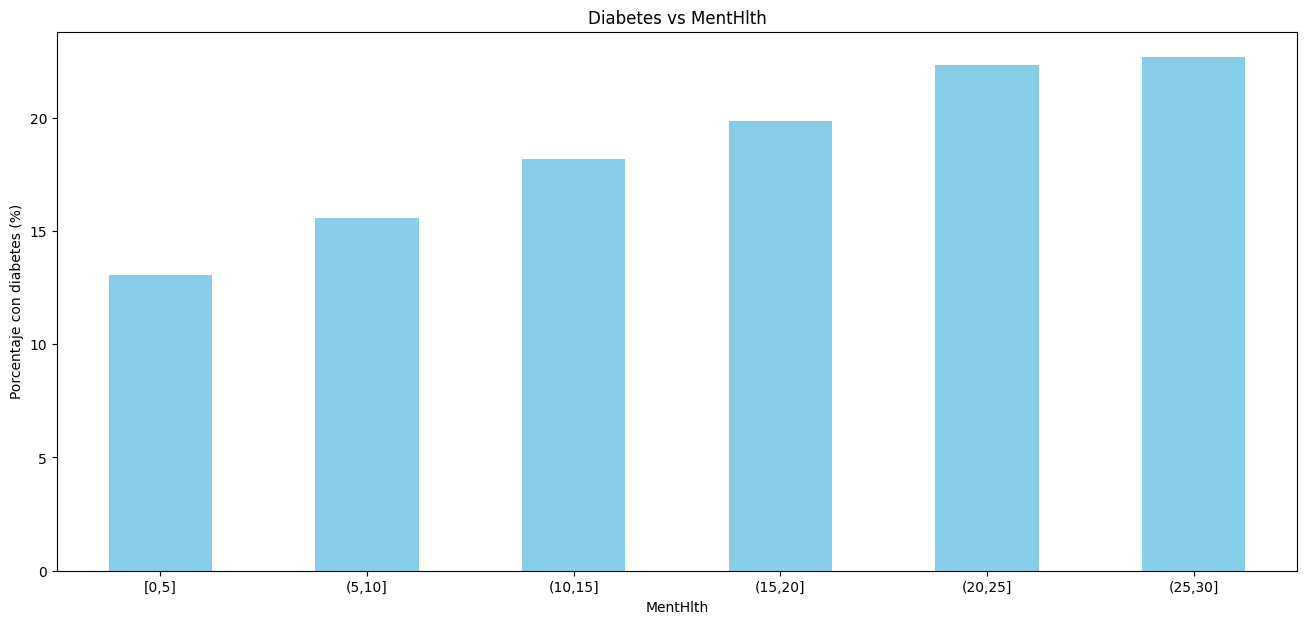

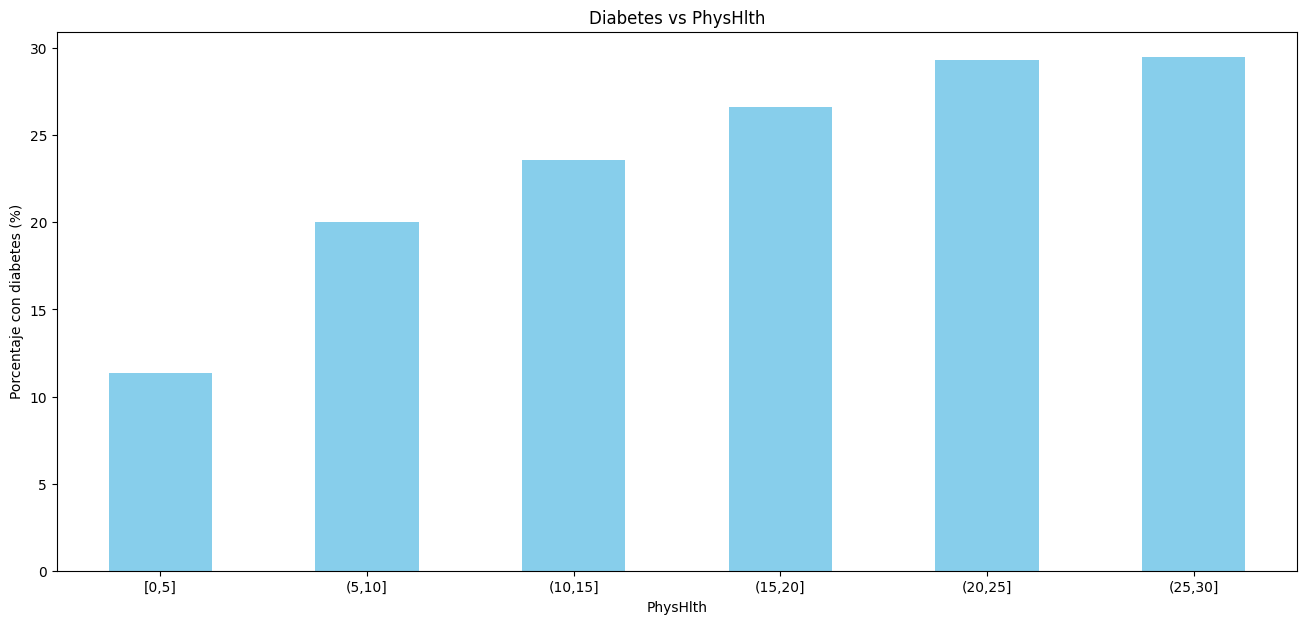

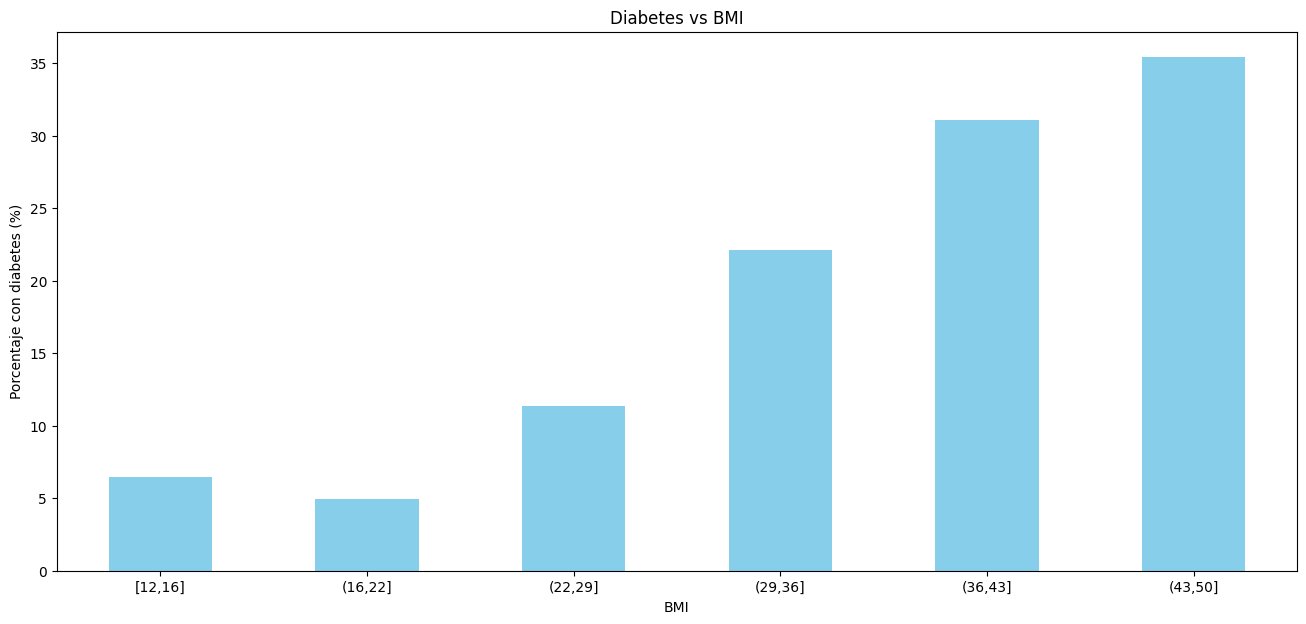

In [335]:
config_categorias = {
    "BMI": {
        "bins": [11, 17, 23, 30, 37, 44, 51],
        "labels": ['[12,16]', '(16,22]', '(22,29]', '(29,36]', '(36,43]', '(43,50]']
    },
    "MentHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    },
    "PhysHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    }
}

for col in numericas:
    
    bins = config_categorias[col]["bins"]
    labels = config_categorias[col]["labels"]
    
    
    grupos = pd.cut(df[col], bins=bins, labels=labels)
    

    diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100
    
    
    plt.figure(figsize=(16, 7))
    diabetes_percent.plot(kind='bar', color='skyblue')
    
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Porcentaje con diabetes (%)')
    plt.xticks(rotation=0)
    plt.show()

**Interpretación:**

Estos gráficos corroboran claras asociaciones entre la diabetes y diversos factores relacionados con la salud física, mental y el Índice de Masa Corporal.

En primer lugar, se evidencia una relación directa entre el deterioro de la salud mental y el aumento en la proporción de personas con diabetes. A medida que se incrementan los días con problemas de salud mental, también aumenta el porcentaje de personas con diagnóstico de diabetes, lo que sugiere una posible interacción entre el bienestar psicológico y el desarrollo o manejo de esta enfermedad.

De manera similar, la salud física también muestra una tendencia marcada: las personas que reportan más días con limitaciones físicas o problemas de salud presentan una mayor prevalencia de diabetes. Esto podría indicar que la diabetes tiende a coexistir con otras condiciones físicas crónicas o que su presencia contribuye al deterioro del estado físico general.

Finalmente, el índice de masa corporal (IMC) muestra una relación especialmente clara: a medida que el IMC aumenta, también lo hace el porcentaje de personas con diabetes. Las tasas más altas se encuentran en los grupos con obesidad severa, lo que refuerza la fuerte asociación entre el exceso de peso y el riesgo de desarrollar diabetes.

## Análisis Multivariado

Para identificar relaciones lineales entre las variables del Dataset, se generó una matriz de correlación mediante un heatmap. Este gráfico muestra el coeficiente de correlación de Pearson (rango: -1 a 1) entre cada par de variables, utilizando una escala de colores (azul para correlaciones negativas, rojo para positivas). Los valores numéricos anotados permiten evaluar posibles dependencias entre variables.


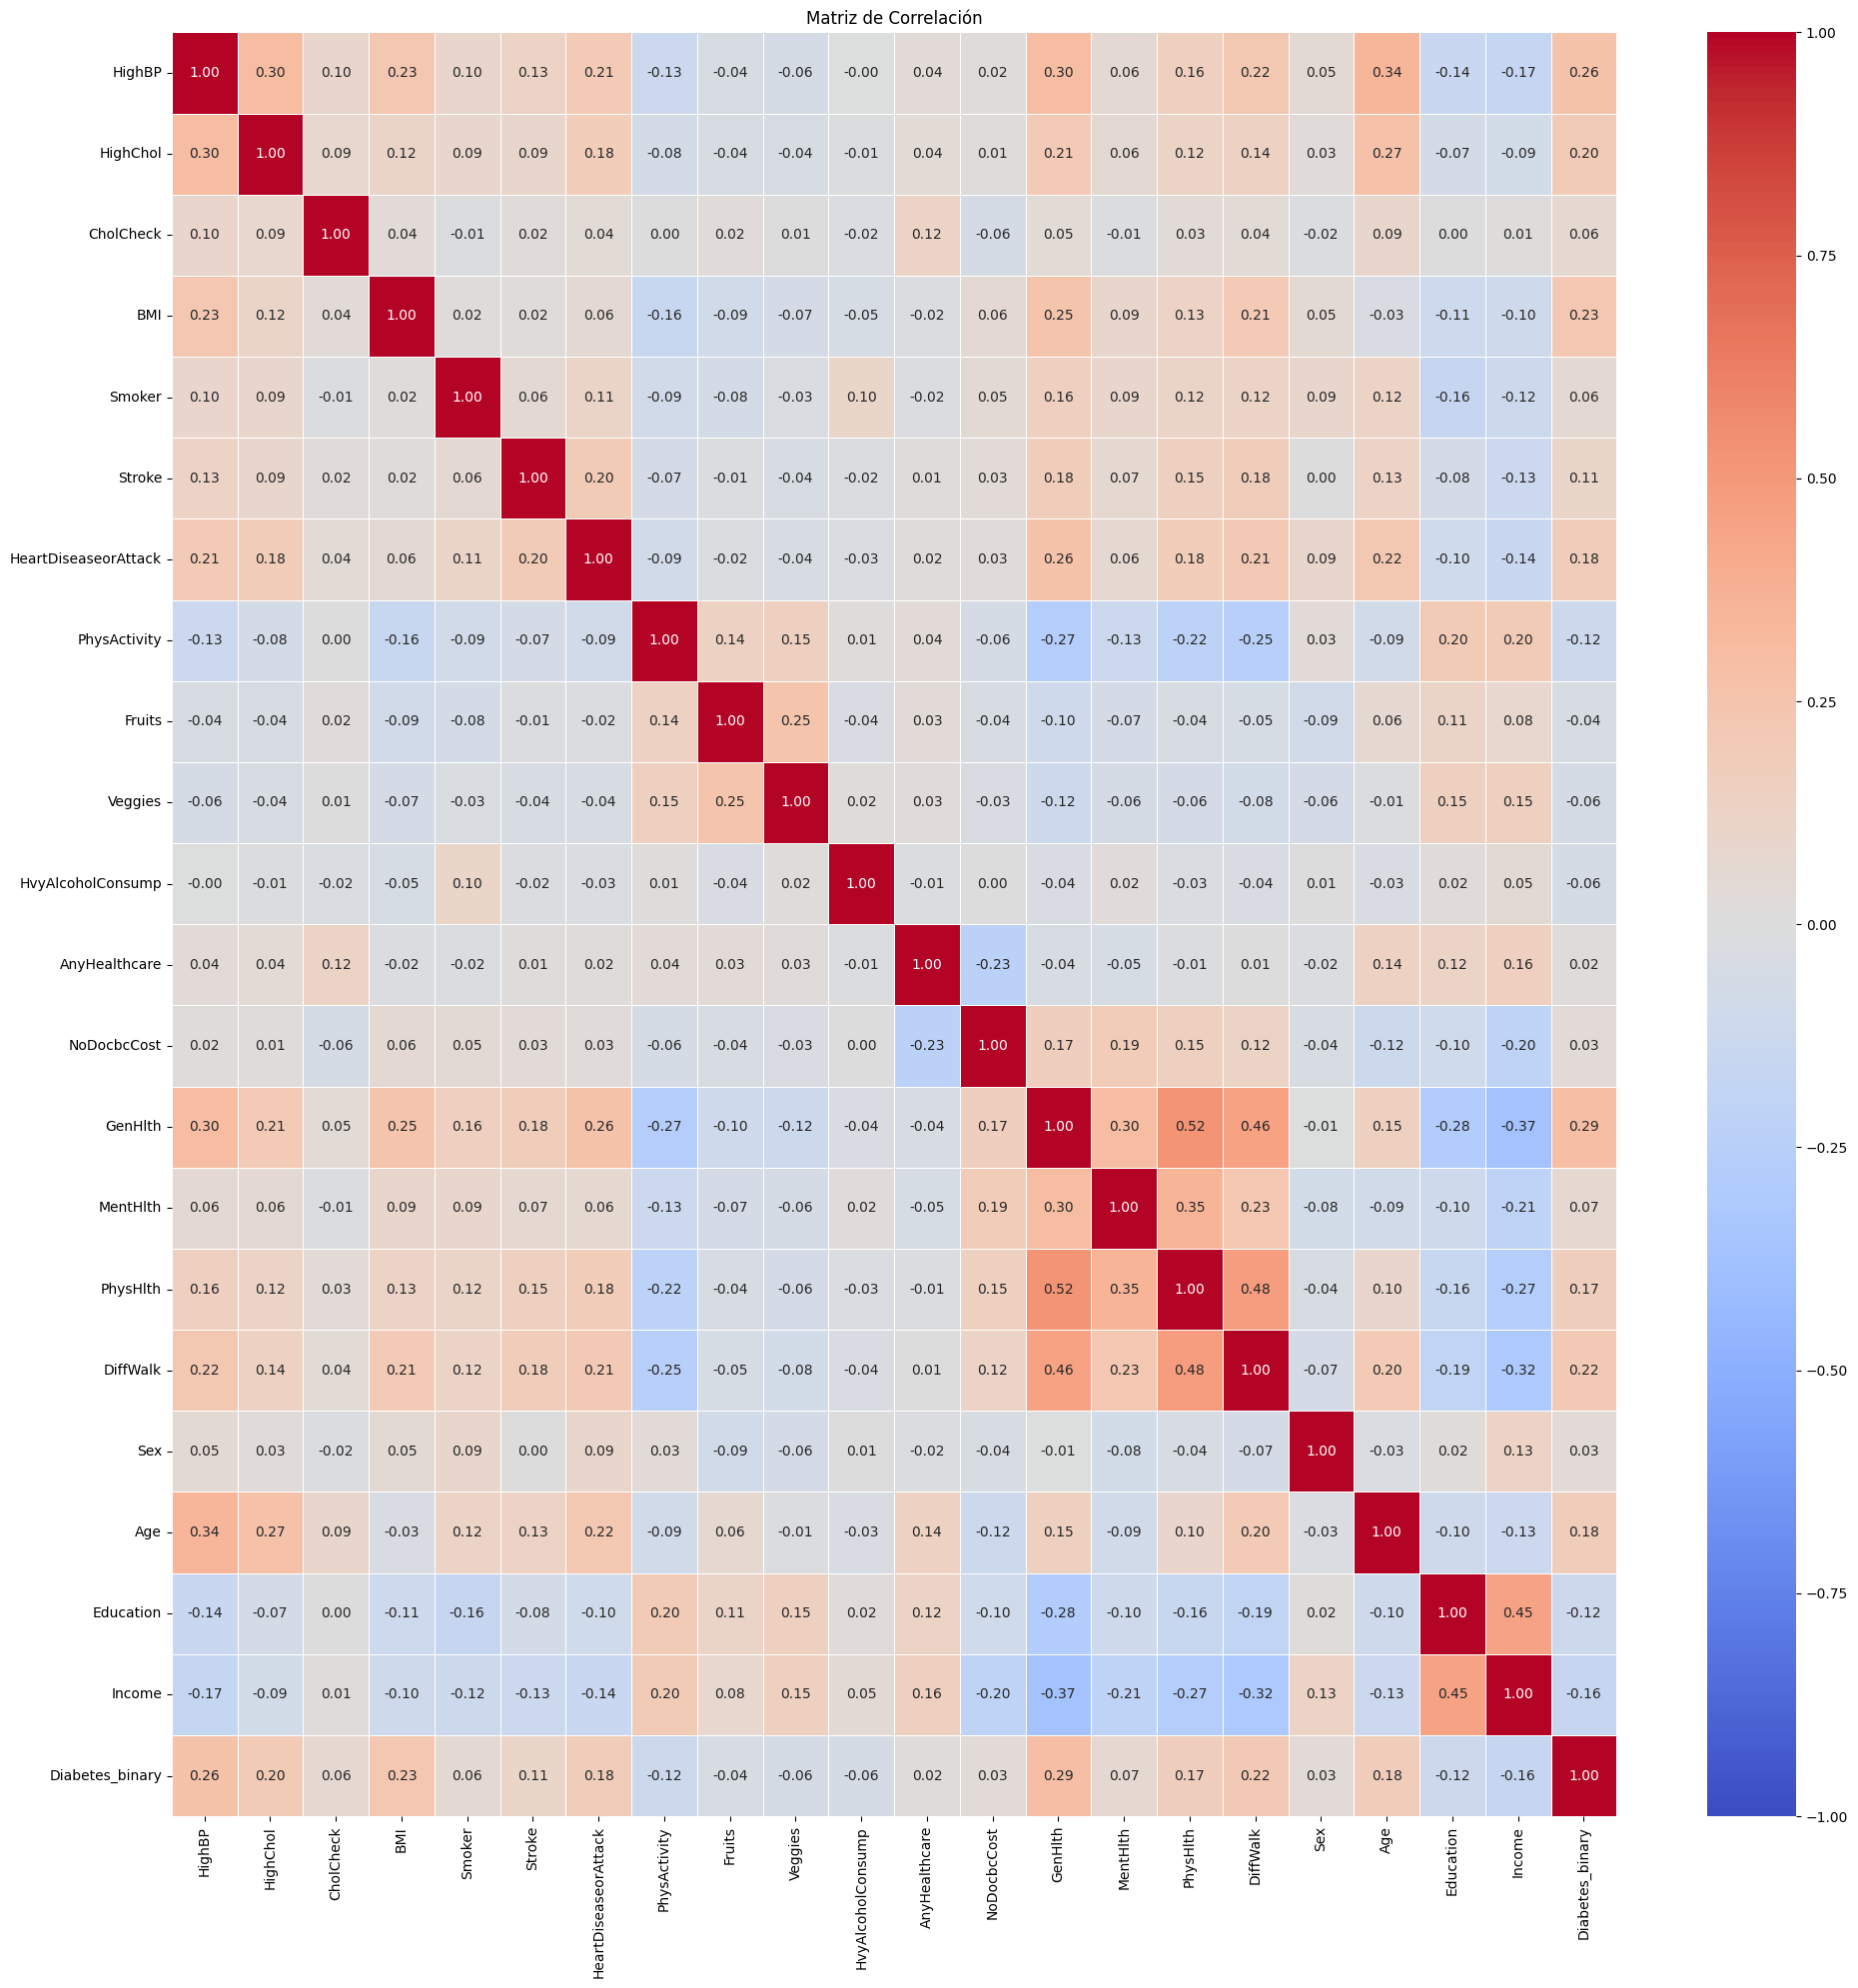

In [336]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          
    cmap="coolwarm",    
    vmin=-1, vmax=1, 
    linewidths=0.5      
)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

**Interpretación:**

El análisis de la matriz de correlación revela patrones clave entre las variables y su asociación con la diabetes (`Diabetes_binary`). Se destacan las siguientes observaciones:

1. Variables con mayor correlación positiva con diabetes:
    - Presión arterial alta `HighBP` (0.26) y índice de masa corporal `BMI` (0.22) muestran una asociación moderada pero significativa, lo que sugiere que estos factores están vinculados a un mayor riesgo de diabetes.
    - Salud general autopercibida `GenHith` (0.29) y dificultad para caminar `DiffWalk` (0.22) también presentan correlaciones positivas, indicando que un peor estado de salud físico y movilidad reducida pueden estar relacionados con la presencia de diabetes.

2. Variables con correlaciones negativas:
    - Actividad física `PhysActivity` (-0.12), nivel educativo `Education` (-0.12) y nivel de ingresos `Income` (-0.16) muestran una relación inversa débil con diabetes, lo que apunta a que estilos de vida más activos, mayores niveles educativos y recursos económicos podrían asociarse a menor prevalencia de la enfermedad.

3. Relaciones entre variables predictoras:
    - `GenHith` está fuertemente correlacionada con `PhysHith` 0.52 y `DiffWalk` 0.46, lo que refleja una interconexión entre salud física, movilidad y percepción general de salud.
    - `Education` e `Income` presentan una correlación positiva entre sí (0.45), sugiriendo que factores socioeconómicos podrían influir en conjunto en los resultados de salud.

4. Correlaciones débiles o nulas:
    - Variables como `AnyHealthcare`, `NoDocbcCost` o `Sex` muestran asociaciones cercanas a cero con diabetes, indicando que su impacto directo es marginal según estos datos.


### Multicolinealidad

A continuación hallamos el VIF el cual determina la fuerza de la correlación entre las variables independientes. Se pronostica tomando una variable y comparándola con todas las demás. La puntuación VIF de una variable independiente representa hasta qué punto la variable se explica por otras variables independientes.

- Un valor `VIF de 1`: Sin multicolinealidad (variable perfectamente independiente).
- Un valor `VIF entre 1 y 5`: Multicolinealidad baja a moderada (no se considera problemática).
- Un valor `VIF entre 5 y 10`: Multicolinealidad moderada a alta (considerada problemática).
- Un valor `VIF superior a 10`: Multicolinealidad alta (preocupación grave, requiere medidas).

In [337]:
def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop = True)
    return(VIF)

VIF_mat = VIF_calculation(X)
display(VIF_mat)

,variable,VIF
0,Education,29.507416
1,CholCheck,23.187436
2,AnyHealthcare,20.839710
3,BMI,18.149913
4,Income,14.156118
5,GenHlth,10.740162
6,Age,9.886830
7,Veggies,5.826886
8,PhysActivity,4.645314
9,Fruits,3.032775


**Interpretación:**

Los valores de VIF obtenidos indican la presencia de multicolinealidad entre las variables predictoras del modelo. Se observa que las variables `Education`, `CholCheck` y `AnyHealthcare` presentan los valores de VIF más elevados (29.51, 23.19 y 20.84, respectivamente), lo que sugiere una fuerte dependencia lineal con otras variables del modelo. Estos resultados superan ampliamente el umbral crítico de `VIF = 5`, e incluso el más estricto de `VIF = 10`, lo que implica que la multicolinealidad podría estar inflando la varianza de los coeficientes de regresión y, por ende, afectando la estabilidad e interpretación del modelo. Variables como `BMI`, `Income` y `GenHlth` también muestran valores preocupantes (18.15, 14.16 y 10.74), aunque en menor grado.

En contraste, las variables restantes (como `Veggies`, `PhysActivity`, `HighBP`, `HighChol` y aquellas con `VIF < 5`) no presentan multicolinealidad significativa, lo que indica que aportan información independiente al modelo. Especialmente, variables como `HvyAlcoholConsump`, `Stroke` y `NoDocbcCost` (`VIF < 1.3`) son prácticamente libres de redundancia.

Estos hallazgos resaltan la necesidad de depurar el modelo para garantizar estimaciones robustas y evitar conclusiones sesgadas.

### Tratamiento de Multicolinealidad

Procedemos a tratar la multicolinealidad mediante la eliminación iterativa de variables con Factor de Inflación de la Varianza (VIF) superior a 10

In [338]:
def delete_multicollinearity(X, VIF_threshold=10):
  # Hacer copia para no modificar el original
  X_reduced = X.copy()
  
  # Calcular VIF inicial
  VIF_mat = VIF_calculation(X_reduced)
  n_VIF = VIF_mat["VIF"][0]
  
  print("VIF inicial:")
  display(VIF_mat)
  
  if (n_VIF <= VIF_threshold):
      print("✓ No hay multicolinealidad significativa!")
      return X_reduced
  
  else:
      print(f"\nEliminando variables con VIF > {VIF_threshold}...")
      variables_eliminadas = []
      
      while (n_VIF > VIF_threshold) and (len(X_reduced.columns) > 1):
          # Eliminar variable con mayor VIF
          variable_a_eliminar = VIF_mat["variable"][0]
          variables_eliminadas.append(variable_a_eliminar)
          X_reduced = X_reduced.drop(variable_a_eliminar, axis=1)
          
          # Recalcular VIF
          VIF_mat = VIF_calculation(X_reduced)
          n_VIF = VIF_mat["VIF"][0] if len(X_reduced.columns) > 0 else 0
          
          print(f"Eliminada: {variable_a_eliminar} (VIF: {n_VIF:.2f})")
      
      print(f"\n✓ Variables eliminadas ({len(variables_eliminadas)}): {variables_eliminadas}")
      print("\nVIF final:")
      display(VIF_mat)
      
      return X_reduced

In [339]:
X_reg = delete_multicollinearity(X_reg, VIF_threshold=10)

VIF inicial:


,variable,VIF
0,Education,28.451799
1,CholCheck,21.975715
2,AnyHealthcare,20.406233
3,Income,14.101497
4,GenHlth,10.061317
5,Age,9.892531
6,Veggies,5.812859
7,PhysActivity,4.647420
8,Fruits,3.032185
9,HighBP,2.296323



Eliminando variables con VIF > 10...
Eliminada: Education (VIF: 20.51)
Eliminada: CholCheck (VIF: 16.49)
Eliminada: AnyHealthcare (VIF: 8.48)

✓ Variables eliminadas (3): ['Education', 'CholCheck', 'AnyHealthcare']

VIF final:


,variable,VIF
0,GenHlth,8.483735
1,Age,8.423971
2,Income,8.077633
3,Veggies,5.555620
4,PhysActivity,4.301873
5,Fruits,2.999369
6,HighBP,2.289372
7,HighChol,2.042537
8,PhysHlth,1.984852
9,Smoker,1.924515


In [340]:
X = delete_multicollinearity(X, VIF_threshold=10)

VIF inicial:


,variable,VIF
0,Education,29.507416
1,CholCheck,23.187436
2,AnyHealthcare,20.839710
3,BMI,18.149913
4,Income,14.156118
5,GenHlth,10.740162
6,Age,9.886830
7,Veggies,5.826886
8,PhysActivity,4.645314
9,Fruits,3.032775



Eliminando variables con VIF > 10...
Eliminada: Education (VIF: 22.24)
Eliminada: CholCheck (VIF: 18.13)
Eliminada: AnyHealthcare (VIF: 14.66)
Eliminada: BMI (VIF: 8.41)

✓ Variables eliminadas (4): ['Education', 'CholCheck', 'AnyHealthcare', 'BMI']

VIF final:


,variable,VIF
0,Age,8.414447
1,GenHlth,8.314430
2,Income,8.039450
3,Veggies,5.554781
4,PhysActivity,4.298214
5,Fruits,2.999004
6,HighBP,2.252082
7,HighChol,2.026692
8,PhysHlth,1.984847
9,Smoker,1.924045


## Análisis de BMI

El análisis tiene como objetivo identificar y evaluar las variables más significativamente relacionadas con el índice de masa corporal (BMI) como variable objetivo, mediante el uso de correlaciones y visualizaciones gráficas. Este proceso es fundamental para la posterior implementación y optimización de modelos de regularización Ridge y Lasso, asegurando la selección de predictores relevantes que mejoren la precisión y generalización de los modelos.

### BMI vs Variables Categóricas

Para profundizar en la relación entre las variables categóricas y el BMI identificada en el heatmap de correlaciones, se generaron boxplots comparativos de las variables con mayor asociación. Estos gráficos permiten visualizar la distribución del BMI entre diferentes categorías y validar las relaciones observadas estadísticamente.

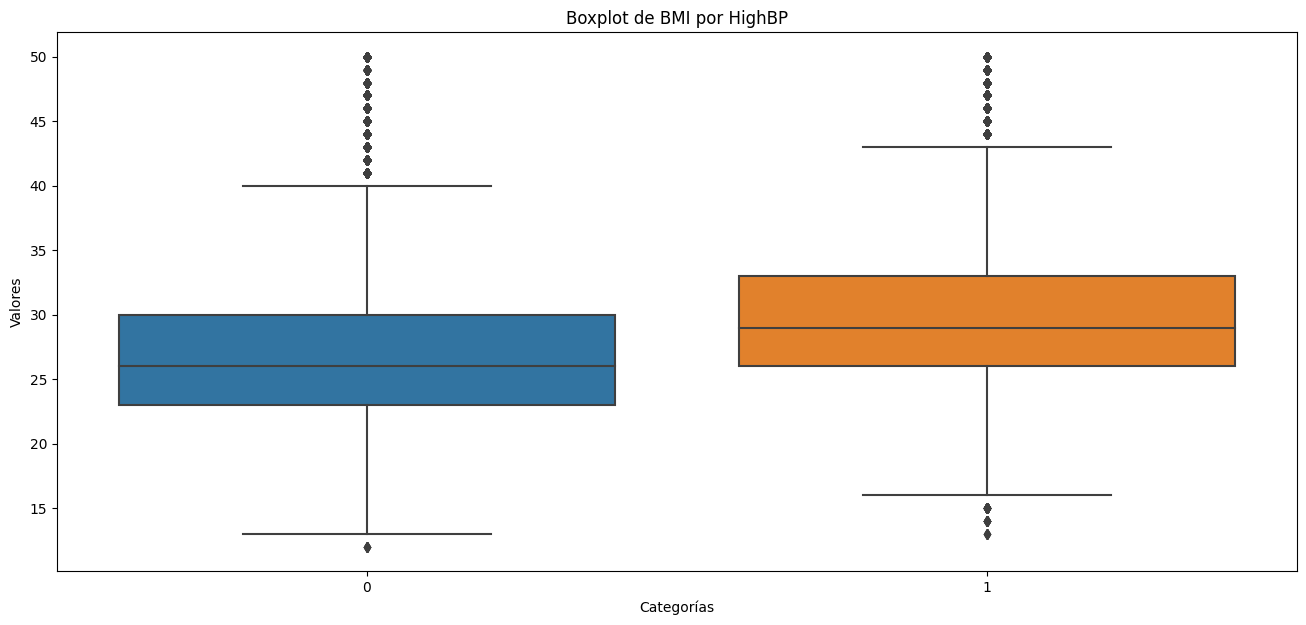

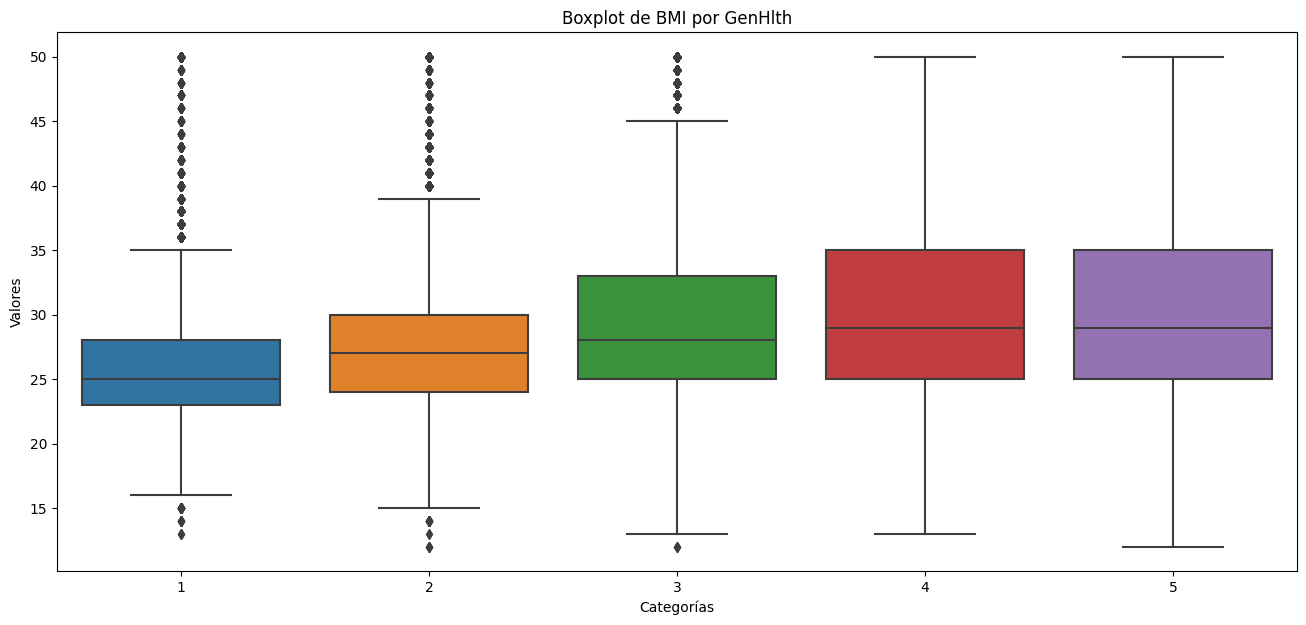

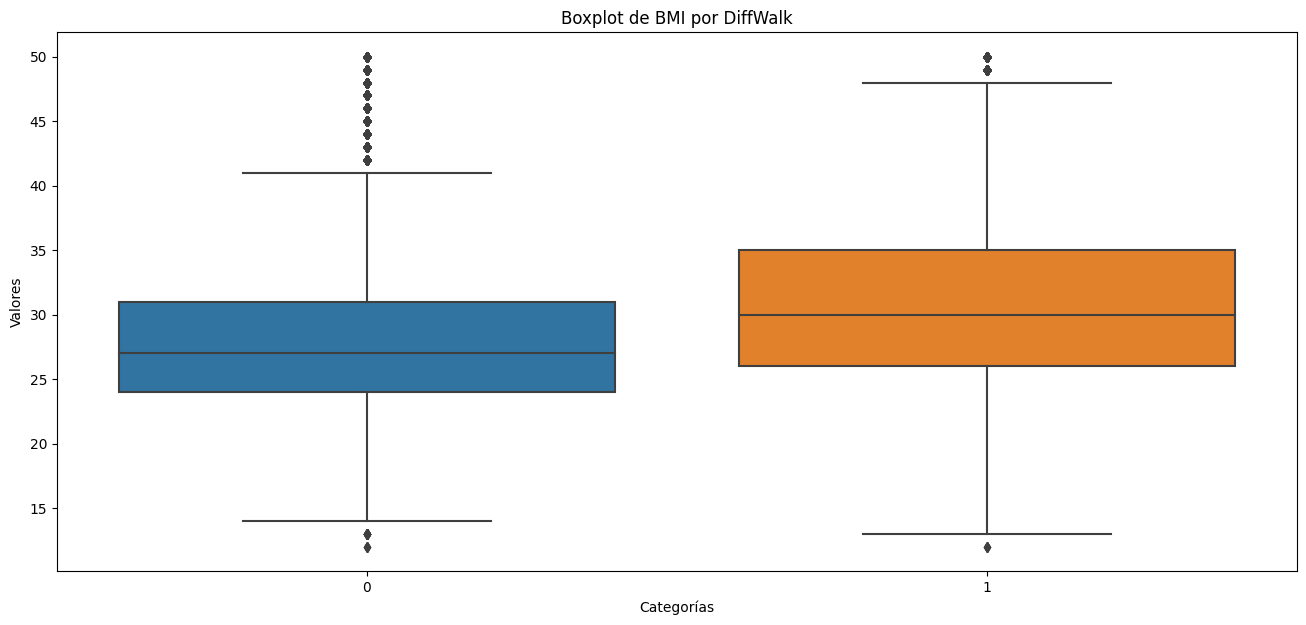

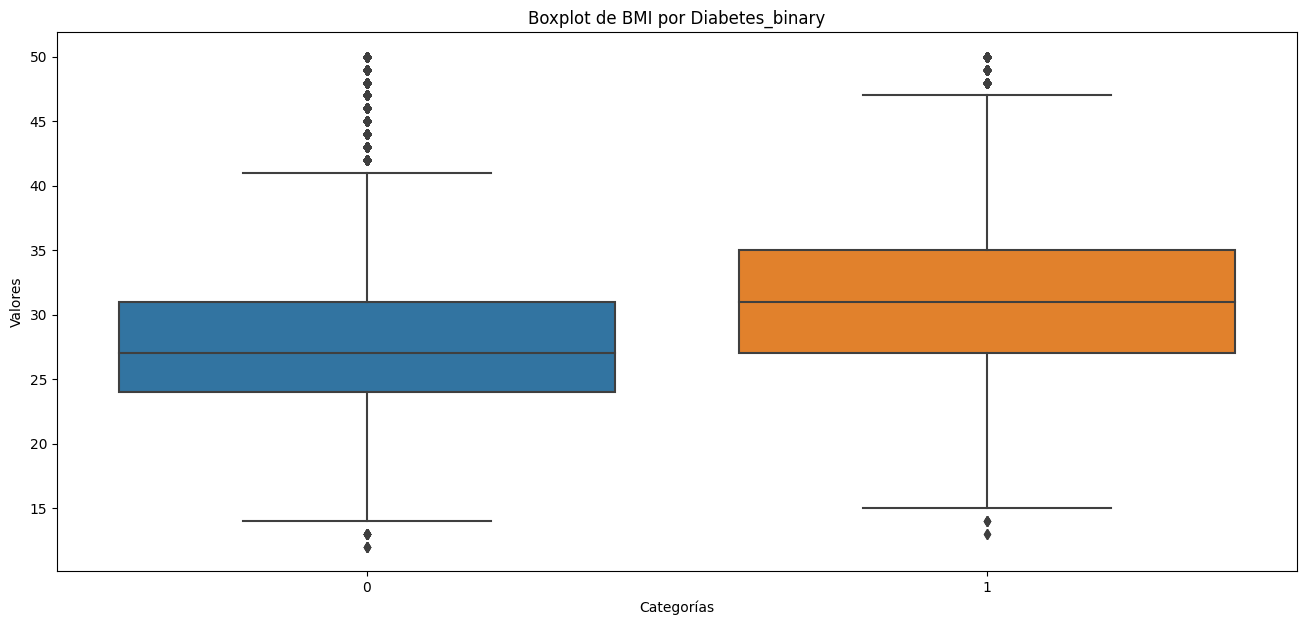

In [341]:
boxplots = ['HighBP','GenHlth', 'DiffWalk', 'Diabetes_binary']

for col in boxplots:
    
    plt.figure(figsize=(16, 7))
    sns.boxplot(x=col, y='BMI', data=df)
    plt.title(f'Boxplot de BMI por {col}')
    plt.xlabel('Categorías')
    plt.ylabel('Valores')
    plt.show()

**Interpretación**

1. Boxplot de `BMI` por `HighBP`:

    - Se observa una clara diferencia en la distribución de BMI entre personas con y sin hipertensión alta.
    - El grupo con HighBP=1 (hipertensos) presenta valores de BMI significativamente más altos.
    - La mediana de BMI es notablemente superior en el grupo con hipertensión alta.
    - Existe mayor variabilidad en el grupo con hipertensión alta, indicando que no todos los hipertensos tienen BMI elevado, pero la tendencia es clara.

2. Boxplot de `BMI` por `GenHlth`:
    - Se evidencia una relación inversa entre la percepción de salud general y el BMI.
    - A medida que GenHlth aumenta (peor salud percibida), el BMI tiende a incrementarse.
    - El grupo con GenHlth=1 (excelente salud) muestra la distribución de BMI más baja.
    - El grupo con GenHlth=5 (mala salud) presenta los valores de BMI más altos.
    - Hay superposición entre grupos pero la tendencia es consistentemente creciente.

3. Boxplot de `BMI` por `DiffWalk`:
    - Diferencias significativas entre grupos.
    - Personas con DiffWalk=1 (dificultad para caminar) presentan BMI notablemente más altos.
    - La distribución del grupo con dificultad para caminar muestra valores más extremos y una mediana elevada.
    - Esto sugiere que el exceso de peso puede estar contribuyendo a problemas de movilidad.

4. Boxplot de `BMI` por `Diabetes_binary`:
    - Contraste evidente entre diabéticos/prediabéticos y no diabéticos.
    - El grupo con Diabetes_binary=1 (diabéticos/prediabéticos) tiene valores de BMI consistentemente más altos.
    - La mediana del grupo diabético es significativamente superior.
    - Menor variabilidad en el grupo no diabético, indicando una distribución más compacta de BMI normal.

Estos hallazgos validan las correlaciones observadas en el heatmap y confirman que estas variables son predictores relevantes para los modelos Ridge y Lasso que se planean implementar.

### BMI vs Variable Númerica

Para profundizar en la relación entre las variables númericas y el BMI identificada en el heatmap de correlaciones, se generaron diagramas de barras comparativos de las variables con mayor asociación (En este caso solo es una variable). Estos gráficos permiten visualizar la distribución del BMI entre diferentes valores y validar las relaciones observadas estadísticamente.

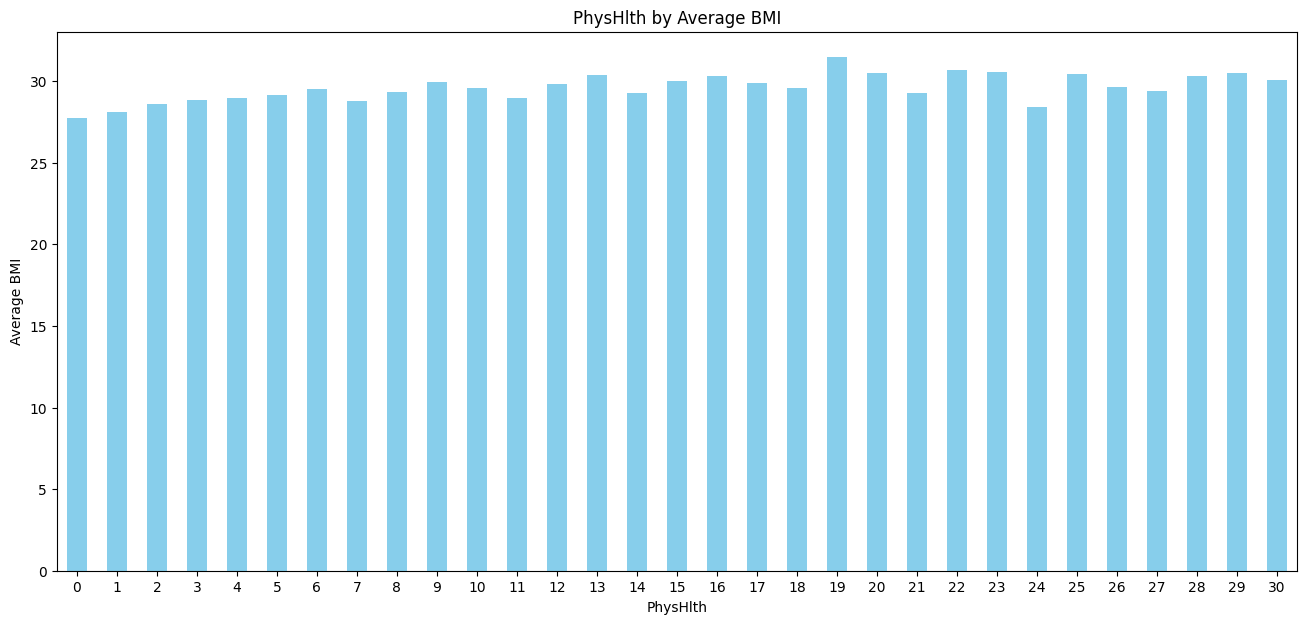

In [342]:
plt.figure(figsize=(16, 7))
py_bmi = df.groupby('PhysHlth')['BMI'].mean()
py_bmi.plot(kind='bar', color = 'skyblue')
plt.title('PhysHlth by Average BMI')
plt.ylabel('Average BMI')
plt.xticks(rotation=0)
plt.show()

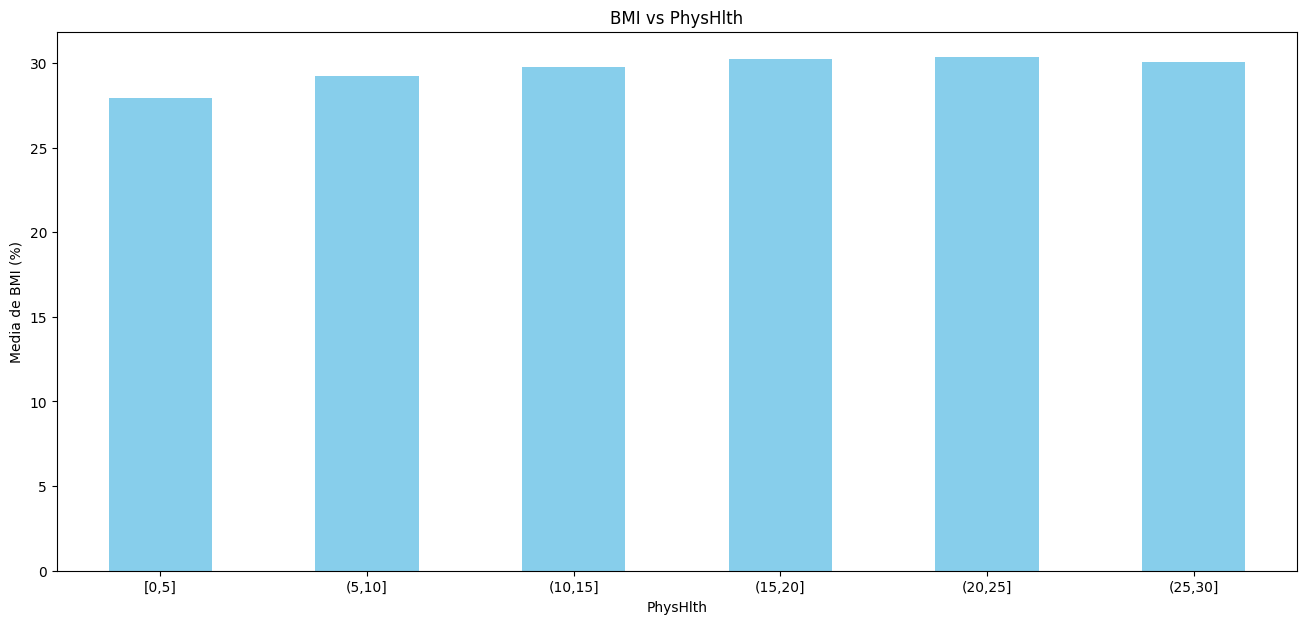

In [343]:
config_py = {
    "PhysHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    }
}

bins = config_py['PhysHlth']["bins"]
labels = config_py['PhysHlth']["labels"]

grupos = pd.cut(df['PhysHlth'], bins=bins, labels=labels)
py_bmi = df.groupby(grupos)['BMI'].mean()
    
plt.figure(figsize=(16, 7))
py_bmi.plot(kind='bar', color='skyblue')
    
plt.title(f'BMI vs PhysHlth')
plt.ylabel('Media de BMI (%)')
plt.xticks(rotation=0)
plt.show()


**Interpretación**

* El BMI promedio se mantiene bastante estable en todos los rangos de PhysHlth, oscilando entre 28 y 30.
* Existe una ligera tendencia creciente: a medida que aumentan los días de mala salud física reportados (de 0–5 a 15–20), también aumenta el BMI promedio.
* Sin embargo, en los últimos intervalos (20–25 y 25–30) el BMI se estabiliza, lo que indica que más días de mala salud física no necesariamente se traducen en un incremento adicional del BMI.

En conclusión, los datos sugieren una asociación moderada entre tener más días de problemas de salud física y un BMI más alto, pero la relación es lineal hasta los 20 días luego se estabiliza.


## Creación del Conjunto de Entrenamiento y Prueba

Para evaluar de manera rigurosa y justa el desempeño final del modelo optimizado, es esencial probarlo en datos que no hayan sido vistos durante el proceso de ajuste de hiperparámetro. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba. El conjunto de entrenamiento (`X_train`, `y_train`) se utilizará para reentrenar el mejor modelo con todos los datos disponibles de entrenamiento, mientras que el conjunto de prueba (`X_test`, `y_test`) se reservará exclusivamente para la evaluación final, proporcionando una estimación no sesgada del rendimiento del modelo en datos nuevos.

Se divide las features (`X`) y la variable objetivo binaria (`y`), utilizando el parámetro `stratify` para garantizar que la proporción de las clases `Diabetes_binary` se mantenga igual en ambos conjuntos, preservando así el balance original.

Además, se crea otro conjunto independiente de entrenamiento y test para la tarea de regresión por medio de `Ridge` y `Lasso`, con la variable objetivo  `BMI`.

Un 20% de los datos se asigna para prueba en ambos casos, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

In [344]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

### Aplicamos balanceo

Dado que la variable Diabetes_binary presenta un desbalanceo significativo, con solo un 13.9% de las observaciones pertenecientes a la clase positiva (personas con diabetes), procedemos a aplicar la técnica `SMOTE` para balancear las clases, creando muestras sintéticas de la clase minoritaria.

In [345]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

### Encoding variables

In [346]:
#Regresión
numericas_reg = [col for col in numericas if col != 'BMI']
categoricas_reg = [col for col in categoricas if col != 'Education']
binarias_reg = [col for col in binarias if col not in ['CholCheck', 'AnyHealthcare']]

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

#Conjunto entrenamiento regresión
X_num = scaler.fit_transform(X_train_reg[numericas_reg])
X_cat = ohe.fit_transform(X_train_reg[categoricas_reg])
X_bin = X_train_reg[binarias_reg]

X_train_reg = np.hstack([X_num, X_cat, X_bin])

#Conjunto test regresión
X_num = scaler.transform(X_test_reg[numericas_reg])
X_cat = ohe.transform(X_test_reg[categoricas_reg])
X_bin = X_test_reg[binarias_reg]

X_test_reg = np.hstack([X_num, X_cat, X_bin])

##----------------------------------------------------------------
#Clasificación
numericas_clf = [col for col in numericas if col != 'BMI']
categoricas_clf = [col for col in categoricas if col != 'Education']
binarias_clf = [col for col in binarias if col not in ['CholCheck', 'AnyHealthcare', 'Diabetes_binary']]

#Conjunto training clasificación
X_num = scaler.fit_transform(X_train_balanced[numericas_clf])
X_cat = ohe.fit_transform(X_train_balanced[categoricas_clf])
X_bin = X_train_balanced[binarias_clf]

X_train= np.hstack([X_num, X_cat, X_bin])

#Conjunto test clasificación
X_num = scaler.transform(X_test[numericas_clf])
X_cat = ohe.transform(X_test[categoricas_clf])
X_bin = X_test[binarias_clf]

X_test = np.hstack([X_num, X_cat, X_bin])

## Regresión Logística - Entrenamiento y Ajuste

### Configuración de la Búsqueda de Hiperparámetro con LogisticRegressionCV

Para optimizar el rendimiento del modelo y encontrar la mejor combinación de hiperparámetro, se configura una búsqueda exhaustiva mediante `LogisticRegressionCV`. Esta estrategia prueba de manera sistemática todas las combinaciones de los valores especificados, utilizando validación cruzada para evaluar de forma robusta el desempeño de cada configuración.

Se implementa la estrategia de validación cruzada con 5 folds.

Además, se define la métrica de evaluación:

- `roc_auc` para clasificación, que mide el area bajo la curva 

El hiperparámetro a optimizar es:

- `C` para Regresión Logística, que controla la inversa de la fuerza de la regularización.

In [347]:
from sklearn.linear_model import LogisticRegressionCV
C = [0.01, 0.1, 1, 10, 100]

logreg_cv = LogisticRegressionCV(Cs=C,cv=5,penalty="l2",solver="liblinear",max_iter=1000,n_jobs=-1,scoring="roc_auc")

### Ejecución de la Búsqueda de Hiperparámetro y Entrenamiento del Modelo

Una vez configurada la estrategia de búsqueda, se procede a ejecutar el entrenamiento del modelo. Este paso es donde se implementa de manera práctica el flujo completo de machine learning definido teóricamente. El método `fit()` de cada objeto `LogisticRegressionCV` no solo entrena el modelo final con la mejor combinación de hiperparámetro encontrada, sino que realiza de manera automatizada y segura todo el proceso de validación cruzada, preprocesamiento y optimización.

In [348]:
logreg_cv.fit(X_train, y_train_balanced)

LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=1000, n_jobs=-1,
                     scoring='roc_auc', solver='liblinear')

In [349]:
print("\n--- Resultados LogisticRegressionCV ---")
print("Mejor C:", logreg_cv.C_[0])  # Mejor valor de C encontrado
print("Score (AUC):", logreg_cv.scores_[1].mean(axis=0).max())  # Mejor score


--- Resultados LogisticRegressionCV ---
Mejor C: 0.01
Score (AUC): 0.8040784850246497


**Interpretación**

El proceso de optimización mediante `LogisticRegressionCV` identificó que el mejor modelo de Regresión Logística se obtiene con los siguientes parámetros:

**Parámetro Óptimo Identificado:**
- **`C = 0.01`**: Este valor indica un nivel alto de regularización, donde el modelo prioriza la generalización sobre el ajuste perfecto a los datos de entrenamiento. Un valor bajo de C (0.01) significa mayor regularización, lo que ayuda a prevenir el sobreajuste.

**Rendimiento Actual del Modelo:**
- **AUC Score: 80.40%** Este resultado representa un desempeño sólido y competitivo, un AUC de 0.8040 indica que el modelo tiene una capacidad del 80.4% para distinguir entre clases positivas y negativas. En el contexto de problemas médicos con desbalanceo de clases, este es un resultado considerablemente bueno, aunque con margen para implementar modelos más avanzados para alcanzar los niveles de precisión requeridos en aplicaciones productivas.


### Evaluación Final del Modelo de Clasificación en el Conjunto de Prueba

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del mejor modelo de Regresión Logística en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train_balanced`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación Logistic Regression
Accuracy: 0.7041942604856513
Precision: 0.2833124078825263
Recall: 0.7341915405290705
F1-score: 0.4088545769654955


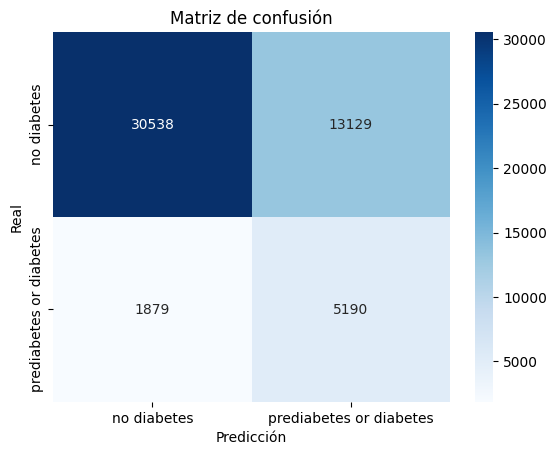

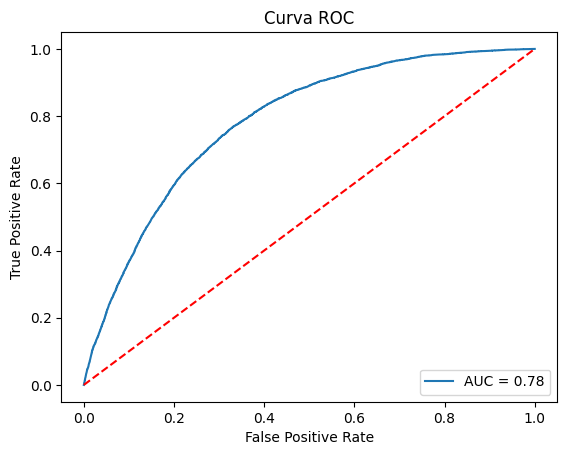

In [350]:
best_logreg = logreg_cv
best_logreg.fit(X_train, y_train_balanced)

y_pred_clf = best_logreg.predict(X_test)
y_pred_proba = best_logreg.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_clf)
prec = precision_score(y_test, y_pred_clf)
rec = recall_score(y_test, y_pred_clf)
f1 = f1_score(y_test, y_pred_clf)

print("Evaluación Logistic Regression")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no diabetes","prediabetes or diabetes"], yticklabels=["no diabetes","prediabetes or diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


**Interpretación**

El modelo de Regresión Logística muestra un panorama mixto que revela importantes oportunidades de optimización:

**Accuracy: 70.41%** Esta métrica superficialmente sugiere un buen desempeño, pero enmascara graves deficiencias en la capacidad predictiva real del modelo.

**Problemas Críticos Identificados:**
- **Precision: 28.33%**: Cuando predice diabetes, solo acierta el 28.33% de las veces. Esto significa que tiene muchos falsos positivos.
- **Recall: 73.41%**: El modelo detecta correctamente el 73.41% de los casos reales de diabetes. Esta es una métrica excelente para la clase minoritaria, indicando que captura la mayoría de los casos positivos.
- **F1-score: 40.88%**: El balance entre precision y recall confirma que, si bien detecta bien los casos reales, genera muchas alarmas falsas.

**Diagnóstico del Modelo:**
El modelo tiene una alta sensibilidad (buen recall) pero baja especificidad (mala precision). 

## KNN Classifier - Entrenamiento y Ajuste

### Configuración de la Búsqueda de Hiperparámetro con KNN

Para optimizar el rendimiento del modelo y encontrar la mejor combinación de hiperparámetro, se configura una búsqueda exhaustiva mediante `GridSearchCV`. Esta estrategia prueba de manera sistemática todas las combinaciones de los valores especificados, utilizando validación cruzada para evaluar de forma robusta el desempeño de cada configuración.

Se implementa la estrategia de validación cruzada con 5 folds.

Además, se define la métrica de evaluación:

- `roc_auc` para clasificación, que mide el area bajo la curva 

El hiperparámetro a optimizar es:

- `n_neighbors` para KNN, que controla el número de vecinos más ceranos a la hora de realizar la predicción.

In [351]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Definir los parámetros a optimizar
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')

### Ejecución de la Búsqueda de Hiperparámetro y Entrenamiento del Modelo 

In [352]:
knn_cv.fit(X_train, y_train_balanced)

print("Mejores parámetros:", knn_cv.best_params_)
print("Mejor score:", knn_cv.best_score_)

Mejores parámetros: {'n_neighbors': 7}
Mejor score: 0.8409612076465256


### Evaluación Final del Modelo de Clasificación en el Conjunto de Prueba

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train_balanced`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación KNN
Accuracy: 0.7464128035320088
Precision: 0.275257811894239
Recall: 0.5021926722308672
F1-score: 0.355604527697085


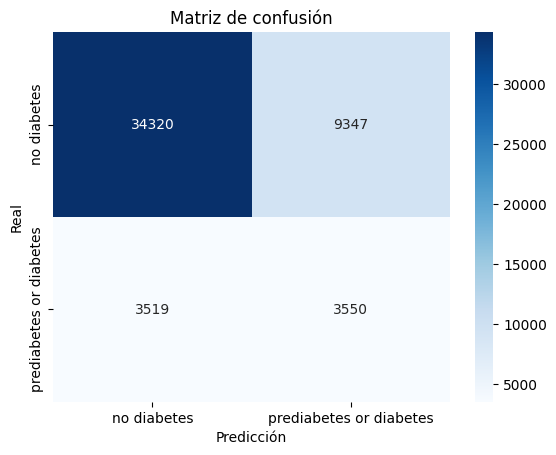

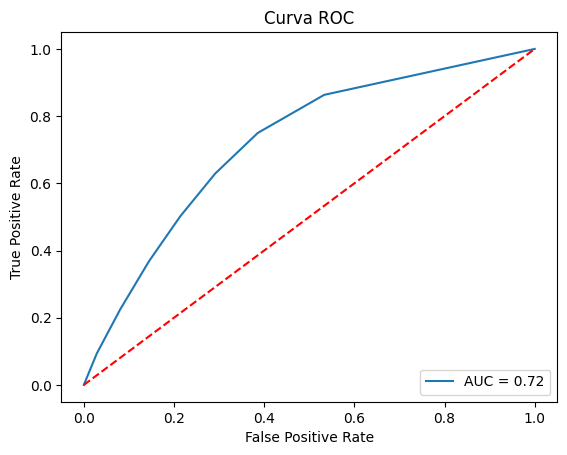

In [353]:
best_knn = knn_cv
best_knn.fit(X_train, y_train_balanced)

y_pred_clf = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_clf)
prec = precision_score(y_test, y_pred_clf)
rec = recall_score(y_test, y_pred_clf)
f1 = f1_score(y_test, y_pred_clf)

print("Evaluación KNN")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no diabetes","prediabetes or diabetes"], yticklabels=["no diabetes","prediabetes or diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

**Interpretación**

El modelo de KNN muestra un desempeño con características específicas que requieren una interpretación precisa:

**Accuracy: 74.64%**  El modelo acierta aproximadamente 3 de cada 4 predicciones, pero esta métrica debe interpretarse con cautela debido al desbalanceo inicial de clases.

**Problemas Críticos Identificados:**
- **Precision: 27.52%**:  Cuando el modelo predice diabetes, solo acierta el 27.52% de las veces. Esto indica un alto número de falsos positivos (diagnósticos erróneos).
- **Recall: 50.21%**: El modelo detecta correctamente el 50.21% de los casos reales de diabetes. Esto significa que pierde aproximadamente la mitad de los casos positivos, lo que representa una oportunidad significativa de mejora.
- **F1-score: 35.56%**: El balance entre precision y recall confirma que el modelo tiene dificultades para equilibrar la detección de casos reales y la minimización de falsas alarmas.

**Diagnóstico del Modelo:**
El modelo tiene capacidad predictiva pero requiere optimización. El trade-off entre recall y precision es característico de problemas con desbalanceo de clases.

## Ridge - Entrenamiento y Ajuste

### Configuración de la Búsqueda de Hiperparámetro con RidgeCV

Para optimizar el rendimiento del modelo de regresión Ridge y encontrar el mejor parámetro de regularización, se configura una búsqueda automatizada mediante RidgeCV. Esta estrategia evalúa de manera sistemática diferentes valores del parámetro de regularización, utilizando validación cruzada para garantizar una evaluación robusta del desempeño de cada configuración.

Se implementa la estrategia de validación cruzada con 5 folds.

El hiperparámetro a optimizar es:

- `alpha` Parámetro de regularización que controla la intensidad de la penalización L2. Valores más altos indican mayor regularización.

In [354]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)

### Ejecución de la Búsqueda de Hiperparámetro y Entrenamiento del Modelo 


In [355]:
ridge_cv.fit(X_train_reg, y_train_reg)

best_alpha = ridge_cv.alpha_
print("--- Resultados RidgeCV ---")
print("Mejor alpha:", best_alpha)

--- Resultados RidgeCV ---
Mejor alpha: 10.0


### Evaluación Final del Modelo de Clasificación en el Conjunto de Prueba

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train_reg`, `y_train_reg`) y se generaron predicciones para el conjunto de prueba. El desempeño se evaluó mediante un conjunto de métricas específicas para problemas de regresión y visualizaciones apropiadas:

- **Métricas de Evaluación**:

    - **MAE (Mean Absolute Error)**: Error absoluto medio que mira la diferencia promedio absoluta entre las predicciones y los valores reales. Es fácil de interpretar y menos sensible a outliers.

    - **RMSE (Root Mean Squared Error)**: Raíz del error cuadrático medio que penaliza más los errores grandes. Es más sensible a outliers que el MAE.

    - **R² (Coeficiente de Determinación)**: Proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica ajuste perfecto, 0 indica que el modelo no mejora sobre la media.


- **Visualizaciones**:

    - **Gráfico de Dispersión Predicciones vs Valores Reales**: Muestra la relación entre las predicciones del modelo y los valores observados, permitiendo identificar patrones de error.



--- Evaluación Ridge (Test) ---
MAE: 4.150376666161271
RMSE: 5.4909560824187205
R²: 0.1780566659357522


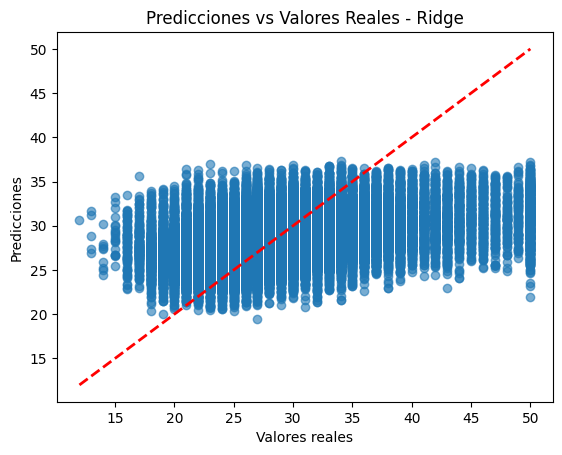

In [356]:
y_pred_ridge = ridge_cv.predict(X_test_reg)

print("\n--- Evaluación Ridge (Test) ---")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)))
print("R²:", r2_score(y_test_reg, y_pred_ridge))

plt.scatter(y_test_reg, y_pred_ridge, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales - Ridge")
plt.show()

**Interpretación**

El modelo muestra un poder predictivo limitado o débil para la tarea de regresión para la que fue entrenado. Logra capturar una parte muy pequeña de la variabilidad de los datos objetivo.

**Análisis de las Métricas Clave:**

*   **R² (Coeficiente de Determinación): 0.178 (17.8%)**
    Este es el indicador más importante. Significa que el modelo, con todas sus variables, solo logra explicar el 17.8% de la variación de la variable objetivo (Y) en los datos de test. El resto (82.2%) queda sin explicar por el modelo y se atribuye a factores o variables no incluidas.
    *   **Diagnóstico:** Un R² tan bajo sugiere que el modelo es poco explicativo. Las características (variables X) utilizadas no tienen una fuerte relación lineal con el resultado que se intenta predecir.

*   **RMSE (Raíz del Error Cuadrático Medio): 5.49**
    *   **Interpretación:** Indica que, en promedio, las predicciones del modelo se desvían aproximadamente 5.49 unidades del valor real. Esta métrica está en las mismas unidades que la variable objetivo.

*   **MAE (Error Absoluto Medio): 4.15**
    *   **Interpretación:** Es similar al RMSE pero menos sensible a los errores muy grandes (outliers). Significa que el error absoluto promedio de las predicciones es de 4.15 unidades.
    *   **Diagnóstico:** El MAE siendo menor que el RMSE confirma que existen algunos errores grandes que están inflando el valor del RMSE. La diferencia entre MAE y RMSE indica la presencia de predicciones con errores considerables.

El modelo de Ridge Regression tiene un desempeño deficiente para este conjunto de datos en particular. La baja capacidad explicativa (R² = 0.178) es la señal más clara.

**Posibles Causas**

1.  **Relación no Lineal:** Los datos pueden tener una relación inherente que no es lineal. La regresión Ridge es un modelo lineal y no puede capturar patrones complejos no lineales. Se podrían probar modelos más complejos que logren capturar los patrones de manera más eficiente.
2.  **Falta de Variables Relevantes:** Es posible que las variables predictoras incluidas en el modelo simplemente no sean lo suficientemente buenas para predecir la variable objetivo. Debido a que el dataset tiene como variable objetivo `Diabetes_binary` por lo tanto los features estan en torno a dicha variable.


## Lasso - Entrenamiento y Ajuste

### Configuración de la Búsqueda de Hiperparámetro con LassoCV

Para optimizar el rendimiento del modelo de regresión Lasso y encontrar el mejor parámetro de regularización, se configura una búsqueda automatizada mediante LassoCV. Esta estrategia evalúa de manera sistemática diferentes valores del parámetro de regularización, utilizando validación cruzada para garantizar una evaluación robusta del desempeño de cada configuración.

Se implementa la estrategia de validación cruzada con 5 folds.

El hiperparámetro a optimizar es:

- `alpha` Parámetro de regularización que controla la intensidad de la penalización L1. Valores más altos indican mayor regularización

In [357]:
from sklearn.linear_model import LassoCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5, n_jobs=-1, max_iter=1000)

### Ejecución de la Búsqueda de Hiperparámetro y Entrenamiento del Modelo 

In [358]:
lasso_cv.fit(X_train_reg, y_train_reg)

best_alpha = lasso_cv.alpha_
print("--- Resultados LassoCV ---")
print("Mejor alpha:", best_alpha)

--- Resultados LassoCV ---
Mejor alpha: 0.001


### Evaluación Final del Modelo de Clasificación en el Conjunto de Prueba

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train_reg`, `y_train_reg`) y se generaron predicciones para el conjunto de prueba. El desempeño se evaluó mediante un conjunto de métricas específicas para problemas de regresión y visualizaciones apropiadas:

- **Métricas de Evaluación**:

    - **MAE (Mean Absolute Error)**: Error absoluto medio que mura la diferencia promedio absoluta entre las predicciones y los valores reales. Es fácil de interpretar y menos sensible a outliers.

    - **RMSE (Root Mean Squared Error)**: Raíz del error cuadrático medio que penaliza más los errores grandes. Es más sensible a outliers que el MAE.

    - **R² (Coeficiente de Determinación)**: Proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica ajuste perfecto, 0 indica que el modelo no mejora sobre la media.


- **Visualizaciones**:

    - **Gráfico de Dispersión Predicciones vs Valores Reales**: Muestra la relación entre las predicciones del modelo y los valores observados, permitiendo identificar patrones de error.


--- Evaluación Lasso (Test) ---
MAE: 4.149861687473329
RMSE: 5.490960292410167
R²: 0.17805540554478183


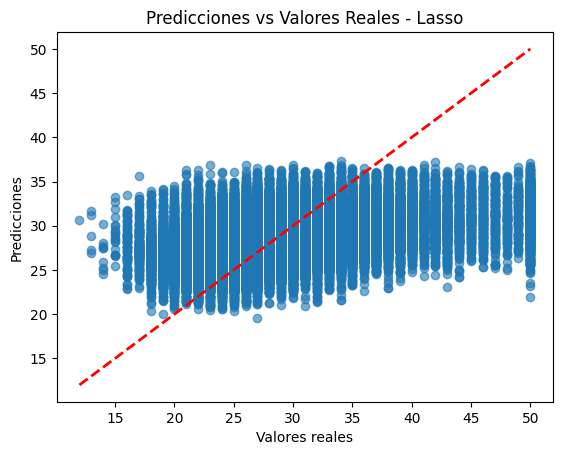

In [359]:
y_pred_lasso = lasso_cv.predict(X_test_reg)

print("\n--- Evaluación Lasso (Test) ---")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso)))
print("R²:", r2_score(y_test_reg, y_pred_lasso))

plt.scatter(y_test_reg, y_pred_lasso, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales - Lasso")
plt.show()

**Interpretación**

El modelo Lasso muestra un poder predictivo casi idéntico al modelo Ridge, lo que indica un desempeño limitado y equivalente para esta tarea. Al igual que Ridge, captura una parte muy pequeña de la variabilidad de los datos.

**Análisis de las Métricas Clave (y comparación con Ridge):**

*   **R² (Coeficiente de Determinación): 0.178 (17.8%)**
    *   **Interpretación:** El valor es prácticamente idéntico al de Ridge (0.178056... vs. 0.178055...). Esto confirma que ambos modelos explican exactamente el 17.8% de la variación de la variable objetivo. La capacidad explicativa de ambos es la misma.

*   **RMSE (Raíz del Error Cuadrático Medio): 5.49096**
    *   **Interpretación:** El error cuadrático medio es idéntico al del modelo Ridge (hasta 5 decimales). Las predicciones se desvían, en promedio, las mismas 5.49 unidades del valor real.

*   **MAE (Error Absoluto Medio): 4.14986**
    *   **Interpretación:** El error absoluto medio es extremadamente similar al de Ridge (4.15038 vs. 4.14986). La diferencia es mínima y no significativa.

**Diagnóstico General del Modelo Lasso:**

El modelo de Lasso Regression tiene un desempeño deficiente, indistinguible del obtenido por el modelo Ridge. Esto es una señal muy poderosa de que la naturaleza de la regularización (L1 para Lasso vs. L2 para Ridge) no ha tenido un impacto diferente en la capacidad predictiva del modelo para este conjunto de datos en particular.

**Posibles Causes**

1.  **Mismo Nivel de Subajuste (Underfitting):** Ambos modelos sufren del mismo problema principal: no logran capturar la relación entre las características y el objetivo. El R² bajo es el síntoma claro de este subajuste.
2.  **Posible Conclusión sobre las Variables:** El hecho de que Lasso, que tiene la propiedad de llevar coeficientes a cero (eliminar variables), obtenga el mismo resultado que Ridge, sugiere que ninguna variable es eliminada por ser irrelevante o que la penalización aplicada no fue suficientemente fuerte para forzar esa eliminación. Todas las variables contribuyen de forma similar (y limitada) en ambos modelos.

En resumen, Lasso no ofrece ninguna ventaja sobre Ridge en este caso específico, y ambos confirman que la solución no se encontrará optimizando modelos lineales, sino cambiando a un enfoque de modelado diferente.

## Conclusión del Modelo de Regresión

El pobre desempeño idéntico de los modelos de **Ridge** y **Lasso** (R² ≈ 0.178) se debe fundamentalmente a una causa raíz: un problema de objetivo y diseño del dataset.

1.  **Desajuste entre el Objetivo del Modelo y el Objetivo del Dataset:**
    *   Se entrenó un modelo de regresión para predecir un valor continuo (BMI).
    *   Sin embargo, el dataset original fue claramente diseñado y recopilado con un propósito completamente diferente: predecir la presencia o ausencia de diabetes (`Diabetes_binary`). Todas las variables, por lo tanto, fueron seleccionadas por su potencial poder explicativo para la diabetes, no para el BMI.

2.  **Falta de Variables Explicativas Relevantes para el BMI:**
    *   El BMI (Índice de Masa Corporal) es una función directa del peso y la altura (BMI = peso / altura²).
    *   Críticamente, este dataset no incluye la variable `peso` ni la variable `altura`. Sin estas dos variables, que son los predictores directos y más importantes por definición, cualquier modelo que intente predecir el BMI se queda sin su principal fuente de información.
    *   Las variables presentes (edad, genéro, si ha tenido chequeos médicos, etc.) pueden tener cierta correlación indirecta con el BMI, pero son sustitutos pobres de las variables fundamentales que faltan. Esto explica por qué el poder explicativo (R²) es tan bajo (~17.8%).

3.  **Los modelos confirman la teoría:**
    *   El hecho de que Ridge y Lasso tuvieran un desempeño virtualmente idéntico confirma que el problema no es de multicolinealidad o overfitting, sino de una falta de señal predictiva en las variables disponibles.
    *   Lasso, que está diseñado para eliminar variables irrelevantes, no encontró ninguna que pudiera descartar para mejorar el modelo, porque ninguna de las variables disponibles es un predictor fuerte del BMI. Todas contribuyen de manera mínima y similar.

En resumen, los modelos de regresión fallaron porque se les pidió resolver un problema (predecir el BMI) para el cual el dataset no contiene la información clave necesaria. El dataset está "cegado" para predecir diabetes, y esa es la tarea para la que sus variables son relevantes. Predecir el BMI a partir de estas variables es una tarea extremadamente difícil y con un techo de precisión muy bajo, como lo demuestran los resultados.

## Conclusión del Modelo de Clasificación

El proceso de modelado para predecir la variable `Diabetes_binary` demuestra de manera contundente que optimizar los datos es tan crucial como elegir el algoritmo correcto, y que la métrica de Accuracy por sí sola es un indicador engañoso y peligroso en conjuntos de datos desbalanceados.

**1. El Engaño del Modelo en Crudo (Sin Ajustes):**
El modelo logístico entrenado con los datos en crudo es el ejemplo perfecto de un modelo ilusionador. Su alto Accuracy (85.9%) oculta un desempeño catastrófico para el objetivo real: identificar pacientes con diabetes/prediabetes.
*   **Recall del 8.6%:** El modelo fallaba espectacularmente, detectando solo 1 de cada 12 casos reales de diabetes. Hubiera dado una falsa sensación de seguridad al dejar sin diagnosticar al 91.4% de los enfermos.
*   **Precision del 48.5%:** Aunque cuando predecía positivo tenía casi un 50% de chance de acertar, era inútil porque casi nunca lo hacía.
*   El modelo, en esencia, aprendió la "ley del mínimo esfuerzo": predecir "no diabetes" para todo, lo que funciona bien para el accuracy pero fracasa en la práctica.

**2. El Éxito de la Optimización de Datos:**
Los ajustes realizados (manejo de desbalanceo, outliers y multicolinealidad) transformaron por completo la utilidad de los modelos, priorizando la detección de casos positivos (Recall) a expensas de una reducción controlada del Accuracy.
*   **Recall del 73.4% (Logístico) y 50.2% (KNN):** Este es el logro más significativo. El modelo logístico ajustado es capaz de identificar 3 de cada 4 casos reales de diabetes, lo que lo convierte en una herramienta valiosa para la detección temprana y la prevención.
*   **Trade-off Controlado:** La mejora radical en el Recall inevitablemente vino con un aumento de Falsos Positivos (disminuyendo la Precision). Sin embargo, este es un trade-off necesario y ético en medicina: es preferible evaluar a más personas sanas de manera preventiva (Falso Positivo) que dejar a un paciente enfermo sin diagnóstico (Falso Negativo).
*   **Mejora General (F1-score):** El incremento sustancial del F1-score (del 14.6% al 40.9% en logística) confirma que el balance global entre Precision y Recall es mucho más saludable después de los ajustes.

Se logró el objetivo principal: desarrollar un modelo clínicamente relevante. Se pasó de un modelo que era prácticamente inútil (a pesar de su alto Accuracy) a uno que, si bien no es perfecto, sirve como un sistema de alerta temprana efectivo. La drástica mejora en el Recall significa que el modelo ahora puede identificar correctamente a la mayoría de los pacientes en riesgo, permitiendo que sean derivados para pruebas de diagnóstico más específicas. La inversión en un preprocesamiento exhaustivo de los datos al manejar el desbalanceo, limpiar outliers y tratar la multicolinealidad fue, sin lugar a dudas, el factor determinante para el éxito del proyecto. Estos resultados, que ya son valiosos por sí mismos, son especialmente prometedores ya que sientan una base sólida de datos bien preparados sobre la cual se pueden aplicar modelos más complejos para capturar patrones no lineales y lograr mejoras adicionales tanto en la precisión como en la capacidad de detección.